# RMBA Group Work - Group C8

### Table of content

Use this table of content to navigate to the respective section.

- [0. Data Import And Cleaning](#0-Data-Import-and-Cleaning)
- [1. Executive Summary](#1-executive-summary)
- [2. Introduction](#2-introduction)
- [3. Exploratory Data Analysis](#3-exploratory-data-analysis)
  - [3.1 Unique Values](#31-unique-values)
  - [3.2 Descriptive Statistics](#32-descriptive-statistics)
  - [3.3 Correlation Matrix](#33-correlation-matrix)
  - [3.4 Data Visualizations with Attrition](#34-data-visualizations-with-attrition)
  - [3.5 Conclusions for the EDA](#35-conclusions-for-the-eda)
- [4. Method 1: Logistic Regression](#4-method-1:-logistic-regression)
  - [4.1 Creating the Logistic Regression Model](##41-creating-the-logistic-regression-model)
  - [4.2 Checking Model Assumptions](#42-checking-model-assumptions)
  - [4.3 R-Squared Metrics](#43-r-squared-metrics)
  - [4.4 Conclusion of Logistic Regression](#44-conclusion-of-logistic-regression)
- [5. Method 2: T-Test](#5-Method-2:-T-Test)
  - [5.1 Introduction](#51-Introduction)
  - [5.2 Hypothesis Testing](#52-hypothesis-testing)
  - [5.3 Conclusion of T-Test](#53-conclusion-of-t-test)
- [6. Conclusion](#6-conclusion)



# 0. Data Import and Cleaning


In [ ]:
!pip install hvplot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.0/161.0 kB 3.8 MB/s eta 0:00:00


In [ ]:
#put all the imports together HERE!!!
import pandas as pd
import io
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import hvplot.pandas
import holoviews as hv
from holoviews import opts
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

First the data is imported and stored as a DataFrame called raw_data


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HR-Employee-Attrition.csv to HR-Employee-Attrition.csv


In [ ]:
raw_data = pd.read_csv(io.BytesIO(uploaded['HR-Employee-Attrition.csv']))

### Checking Data Structure, Types, Missing Values and Duplicates


Before diving into the analysis, we wanted to check the basic structure of the dataset, including its dimensions and the data types of each column. Additionally, we will look for any missing values to ensure the dataset is complete and identify where we might need to handle gaps in the data. We also checked for duplicated values to ensure the integrity of our dataset. This step ensures the dataset is well-prepared for analysis.



In [ ]:
raw_data.shape # Getting the dimensions of the data

(1470, 35)

In [ ]:
raw_data.dtypes # Basic information about the dataset

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [ ]:
raw_data.isnull().sum() # Checking for missing values

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


Upon review, we found that none of the columns contain any missing values.

In [ ]:
raw_data.duplicated().sum() # Check for duplicate rows

0

Upon review, we found that there are no duplicate rows in the dataset.

This is a positive indicator, as it means we can proceed with our analysis without needing to handle any gaps and it means our analysis will not be skewed by redundant entries, allowing us to draw more accurate conclusions.

### Converting Categorical Variables to Numerical Format


In this step, we transform the raw data by converting non-numerical values into numerical formats.

The transformation process includes two key methods:

* **Binary Mapping:** This technique is applied to categorical variables with two categories, converting values such as 'Yes'/'No' and 'Male'/'Female' into binary values (1/0).

* **One-Hot Encoding:** This method is utilized for categorical variables with more than two categories. We applied one-hot encoding to columns such as 'BusinessTravel', 'Department', 'EducationField', 'JobRole', and 'MaritalStatus', transforming these categories into separate binary columns to represent each category without introducing any ordinal relationships.

These transformations ensure that our dataset is properly structured for analysis, allowing us to efficiently work with numerical data.

In [ ]:
t_data = raw_data.copy() # Create a copy of the raw_data to avoid modifying the original dataset

# Apply one-hot encoding to selected categorical columns, storing the result as integers
t_data = pd.get_dummies(t_data, columns=['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'], dtype=int)

# Rename the columns to replace spaces with underscores for better compatibility
t_data.rename(columns=lambda x: x.replace(' ', '_').replace('-', '_'), inplace=True)

# Convert 'OverTime', 'Gender', and 'Attrition' columns from 'Yes'/'No' or 'Male'/'Female' to binary values (1/0)
t_data['OverTime'] = t_data['OverTime'].map({'Yes': 1, 'No': 0})
t_data['Gender'] = t_data['Gender'].map({'Male': 1, 'Female': 0})
t_data['Attrition'] = t_data['Attrition'].map({'Yes':  1, 'No': 0})

t_data.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Laboratory_Technician,JobRole_Manager,JobRole_Manufacturing_Director,JobRole_Research_Director,JobRole_Research_Scientist,JobRole_Sales_Executive,JobRole_Sales_Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,1,2,0,94,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,1,2,3,1,61,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,1,4,4,1,92,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,1,5,4,0,56,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,7,1,1,40,...,1,0,0,0,0,0,0,0,1,0


The dataset is now clean, well-structured, and ready for the next stage.

# 1. Executive Summary


This report explores the influence of age and work-life balance on employee attrition, specifically examining whether younger employees place greater importance on work-life balance when deciding to leave their jobs compared to older employees. The research addressed the following question:

**"How do age and work-life balance influence employee attrition, and do younger employees value work-life balance more than older employees when deciding to leave?"**

To answer this, two hypotheses were formulated and tested:

- **H1**: Younger employees are more likely to quit their jobs, with the likelihood of quitting decreasing as they age.
- **H2**: Younger employees (under 36) value work-life balance more than older employees, and this preference influences their attrition behavior.

**Key Findings**

1. **Age and Attrition (H1)**: Analysis showed that younger employees (under 36) experienced a significantly higher attrition rate (21.95%) compared to their older counterparts (10.39%). Logistic regression confirmed a modderate negative relationship between age and attrition (coefficient = -0.0456, p < 0.001), with an odds ratio of 0.955, suggesting that the likelihood of quitting decreases by approximately 4.5% with each additional year of age. These findings support H1, indicating that younger employees are more likely to leave the company.

2. **Work-Life Balance and Attrition (H2)**: While poor work-life balance was linked to higher attrition rates overall, a t-test comparing work-life balance scores between younger (under 36) and older employees (36 and above) who quit showed no statistically significant difference. This indicates that younger employees do not prioritize work-life balance more than older employees when deciding to leave, leading to the rejection of H2. Thus, work-life balance alone is not a key factor driving higher attrition rates among younger employees.

**Conclusion**

Younger employees are more likely to leave their jobs, but this cannot be solely attributed to differences in work-life balance preferences compared to older employees. The rejection of H2 suggests that other factors, such as overtime and job satisfaction, are likely contributing to the higher attrition rates among younger workers. However, while work-life balance alone was not found to be a decisive factor, related variables such as business travel, distance from home, environment satisfaction, job involvement, job satisfaction, overtime, and training times last year might offer deeper insights. Connecting these findings to broader themes like the 'New Work' movement could provide additional understanding of work culture preferences and attrition behaviors, especially when comparing older and younger employees. Further research is needed to confirm these ideas, as the current findings only point us toward possible areas for deeper investigation. Taking a closer look at these related factors could help us better understand what's really driving employee attrition and uncover more subtle differences in work culture preferences across different age groups.



# 2. Introduction



Employee attrition is a critical issue for organizations, impacting productivity, morale, and operational costs. Understanding the factors that drive employees to leave their jobs is essential for developing effective retention strategies. This study investigates how age and work-life balance influence employee attrition, focusing on whether younger employees value work-life balance more than older employees when deciding to leave the company.

The dataset used in this analysis consists of several employee characteristics, covering both demographic and job-related variables. Key demographic variables include **Age**, **Gender**, **Marital Status**, and **Education Level**. Job-related variables include **Job Role**, **Department**, **Monthly Income**, **Years at the Company**, and **Overtime**. Additionally, the dataset captures behavioral factors such as **Job Satisfaction**, **Work-Life Balance**, and **Attrition**, where the latter serves as the target variable indicating whether an employee has left the company.

In this analysis, we aim to answer the research question:

> **"How do age and work-life balance influence employee attrition, and do younger employees value work-life balance more than older employees in their decision to leave the company?"**

To address this, we formulate two hypotheses:

- **H1:** Younger employees are more likely to quit their job, and the likelihood of quitting decreases as they get older. We will test this hypothesis using logistic regression, where we model the probability of employee attrition based on age. A negative coefficient for age would indicate that as employees get older, they are less likely to leave.
  
- **H2:** Younger employees (under 36) value work-life balance more than older employees, and this is reflected in their attrition behavior. Specifically, we hypothesize that younger employees who leave tend to have worse work-life balance scores than older employees who leave. We will test this hypothesis by comparing the work-life balance scores of the two age groups (under 36 and 36 and above) using statistical methods to determine if the differences are significant.

Through this analysis, we aim to shed light on the role of age and work-life balance in employee attrition. By examining these factors, we hope to offer insights that can guide organizations in developing targeted strategies to reduce turnover, particularly by addressing the work-life balance needs of younger employees.



# 3. Exploratory Data Analysis

## 3.1 Unique Values

To gain a deeper understanding of our dataset, we examined the unique values in each column. This analysis serves several purposes:

* **Identify Categorical Variables:** By reviewing the unique values, we can pinpoint categorical variables that may require further transformation, such as encoding.

* **Detect Inconsistencies:** This process helps reveal any inconsistencies in the data, such as variations in naming conventions that could lead to erroneous analyses.

* **Highlight Outliers:** Analyzing the unique values can also uncover potential outliers or unexpected values that may need further investigation, ensuring our dataset is clean and reliable for subsequent analyses.



In [ ]:
# Print unique values to give us a perception of the values for each one of the variables
print("Ages:")
print(sorted(raw_data.Age.unique()))
print("\nAttrition (Yes/No):")
print(sorted(raw_data.Attrition.unique()))
print("\nBusiness Travel :")
print(sorted(raw_data.BusinessTravel.unique()))
print("\nDaily Rates:")
print(sorted(raw_data.DailyRate.unique()))
print("\nDepartments:")
print(sorted(raw_data.Department.unique()))
print("\nDistances From Home:")
print(sorted(raw_data.DistanceFromHome.unique()))
print("\nEducation Levels:")
print(sorted(raw_data.Education.unique()))
print("\nEducation Fields:")
print(sorted(raw_data.EducationField.unique()))
print("\nEmployee Counts:")
print(sorted(raw_data.EmployeeCount.unique()))
print("\nEmployee Numbers:")
print(sorted(raw_data.EmployeeNumber.unique()))
print("\nEnvironment Satisfaction Ratings:")
print(sorted(raw_data.EnvironmentSatisfaction.unique()))
print("\nGenders:")
print(sorted(raw_data.Gender.unique()))
print("\nHourly Rates:")
print(sorted(raw_data.HourlyRate.unique()))
print("\nJob Involvement Ratings:")
print(sorted(raw_data.JobInvolvement.unique()))
print("\nJob Levels:")
print(sorted(raw_data.JobLevel.unique()))
print("\nJob Roles:")
print(sorted(raw_data.JobRole.unique()))
print("\nJob Satisfaction Ratings:")
print(sorted(raw_data.JobSatisfaction.unique()))
print("\nMarital Statuses:")
print(sorted(raw_data.MaritalStatus.unique()))
print("\nMonthly Incomes:")
print(sorted(raw_data.MonthlyIncome.unique()))
print("\nMonthly Rates:")
print(sorted(raw_data.MonthlyRate.unique()))
print("\nNumber of Companies Worked:")
print(sorted(raw_data.NumCompaniesWorked.unique()))
print("\nOver 18:")
print(sorted(raw_data.Over18.unique()))
print("\nOvertime:")
print(sorted(raw_data.OverTime.unique()))
print("\nPercent Salary Hikes:")
print(sorted(raw_data.PercentSalaryHike.unique()))
print("\nPerformance Ratings:")
print(sorted(raw_data.PerformanceRating.unique()))
print("\nRelationship Satisfaction Ratings:")
print(sorted(raw_data.RelationshipSatisfaction.unique()))
print("\nStandard Hours:")
print(sorted(raw_data.StandardHours.unique()))
print("\nStock Option Levels:")
print(sorted(raw_data.StockOptionLevel.unique()))
print("\nTotal Working Years:")
print(sorted(raw_data.TotalWorkingYears.unique()))
print("\nTraining Times Last Year:")
print(sorted(raw_data.TrainingTimesLastYear.unique()))
print("\nWork-Life Balance Ratings:")
print(sorted(raw_data.WorkLifeBalance.unique()))
print("\nYears At Company:")
print(sorted(raw_data.YearsAtCompany.unique()))
print("\nYears In Current Role:")
print(sorted(raw_data.YearsInCurrentRole.unique()))
print("\nYears Since Last Promotion:")
print(sorted(raw_data.YearsSinceLastPromotion.unique()))
print("\nYears With Current Manager:")
print(sorted(raw_data.YearsWithCurrManager.unique()))

Ages:
[18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]

Attrition (Yes/No):
['No', 'Yes']

Business Travel :
['Non-Travel', 'Travel_Frequently', 'Travel_Rarely']

Daily Rates:
[102, 103, 104, 105, 106, 107, 109, 111, 115, 116, 117, 118, 119, 120, 121, 124, 125, 128, 129, 130, 131, 132, 134, 135, 136, 138, 140, 141, 142, 143, 144, 145, 146, 147, 148, 150, 152, 153, 154, 155, 156, 157, 160, 161, 163, 164, 167, 168, 170, 172, 174, 176, 177, 179, 180, 181, 182, 185, 188, 189, 192, 193, 194, 195, 196, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 210, 211, 213, 216, 217, 218, 219, 224, 228, 230, 231, 232, 234, 237, 238, 240, 241, 243, 244, 247, 248, 249, 251, 252, 253, 254, 256, 258, 261, 263, 264, 265, 266, 267, 268, 269, 271, 277, 279, 280, 282, 285, 286, 287, 288, 289, 290, 294, 296, 299, 300, 301, 302, 303, 304, 305, 306, 307, 309, 310, 311, 313, 314, 316, 317,

Upon review, we noticed that the `Over18` and `StandardHours` columns contain constant values, which provide no meaningful insights for our analysis. As such, we have decided to eliminate these columns to streamline our dataset and focus on more informative variables.

In [ ]:
t_data.drop(['Over18', 'StandardHours'], axis=1, inplace=True) # Delete the 'Over18' and 'StandardHours' because they are a constant

## 3.2 Descriptive Statistics

A detailed examination of the descriptive statistics in the HR Attrition dataset provides an initial glimpse into employee demographics, job satisfaction, and other factors potentially related to attrition.

 By analyzing key metrics such as the mean, median, and standard deviation, this analysis offers a preliminary understanding of the data, helping to identify possible trends and patterns that may warrant further investigation. While this analysis is not intended to serve as the basis for decision-making or retention strategies, it offers valuable first insights into what might be important to employees and highlights areas for future, more detailed analysis.

 In the code, we have separated the analysis into categorical and numerical variables to ensure that appropriate statistical measures are applied to each data type, leading to clearer and more meaningful insights at this exploratory stage.



In [ ]:
pd.set_option('display.max_columns', None)  # Ensure all columns are displayed

# Identify numerical and categorical columns
categorical_columns = [col for col in t_data.columns if '_' in col]
numeric_columns = [col for col in t_data.columns if col not in categorical_columns]

# Select only numeric columns for descriptive statistics
numeric_t_data = t_data[numeric_columns]
categorical_t_data = t_data[categorical_columns]

# Perform descriptive statistics and round to 2 decimal places for the full dataset
eda = t_data.describe().round(2)

# Calculate additional statistics for the full dataset
mean = t_data.mean().to_frame().T.rename(index={0: 'mean'})
median = t_data.median().to_frame().T.rename(index={0: 'median'})
mode = t_data.mode().iloc[0].to_frame().T.rename(index={0: 'mode'})
std_dev = t_data.std().to_frame().T.rename(index={0: 'std_dev'})
variance = t_data.var().to_frame().T.rename(index={0: 'variance'})
skewness = t_data.skew().to_frame().T.rename(index={0: 'skew'})
kurtosis = t_data.kurt().to_frame().T.rename(index={0: 'kurtosis'})

# Concatenate all statistics into a single DataFrame
eda = pd.concat([eda, median, mode, std_dev, variance, skewness, kurtosis], axis=0)

# Reset the index to avoid duplicate index issues
eda.reset_index(inplace=True)

# Set a new index without losing the statistics names
eda.set_index('index', inplace=True)

# Reorder the DataFrame to group related statistics together
new_order = ['count', 'mean', 'median', 'mode', 'std_dev', 'variance', 'skew', 'kurtosis', 'min', '25%', '50%', '75%', 'max']

# Ensure that the new order only contains existing labels
new_order = [stat for stat in new_order if stat in eda.index]
eda = eda.loc[new_order]

# Create views for numeric and categorical statistics
enumeric_view = eda[numeric_columns]
edcategorical_view = eda.loc[['count', 'mean', 'std_dev', 'variance', 'skew', 'kurtosis'], categorical_columns]

# Set float format to show 2 decimal places
pd.set_option('display.float_format', '{:.2f}'.format)

# Display the final statistics DataFrames
enumeric_view  # Display the statistics for numeric columns


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
index,,,,,,,,,,,,,,,,,,,,,,,,,,,,
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,0.16,802.49,9.19,2.91,1.00,1024.87,2.72,0.60,65.89,2.73,2.06,2.73,6502.93,14313.10,2.69,0.28,15.21,3.15,2.71,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
median,36.00,0.00,802.00,7.00,3.00,1.00,1020.50,3.00,1.00,66.00,3.00,2.00,3.00,4919.00,14235.50,2.00,0.00,14.00,3.00,3.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
mode,35.00,0.00,691.00,2.00,3.00,1.00,1.00,3.00,1.00,66.00,3.00,1.00,4.00,2342.00,4223.00,1.00,0.00,11.00,3.00,3.00,0.00,10.00,2.00,3.00,5.00,2.00,0.00,2.00
std_dev,9.14,0.37,403.51,8.11,1.02,0.00,602.02,1.09,0.49,20.33,0.71,1.11,1.10,4707.96,7117.79,2.50,0.45,3.66,0.36,1.08,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
variance,83.46,0.14,162819.59,65.72,1.05,0.00,362433.30,1.19,0.24,413.29,0.51,1.23,1.22,22164857.07,50662878.17,6.24,0.20,13.40,0.13,1.17,0.73,60.54,1.66,0.50,37.53,13.13,10.38,12.73
skew,0.41,1.84,-0.00,0.96,-0.29,0.00,0.02,-0.32,-0.41,-0.03,-0.50,1.03,-0.33,1.37,0.02,1.03,0.96,0.82,1.92,-0.30,0.97,1.12,0.55,-0.55,1.76,0.92,1.98,0.83
kurtosis,-0.40,1.40,-1.20,-0.22,-0.56,0.00,-1.22,-1.20,-1.84,-1.20,0.27,0.40,-1.22,1.01,-1.21,0.01,-1.07,-0.30,1.70,-1.18,0.36,0.92,0.49,0.42,3.94,0.48,3.61,0.17
min,18.00,0.00,102.00,1.00,1.00,1.00,1.00,1.00,0.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,0.00,11.00,3.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00


In [ ]:
edcategorical_view  # Display the statistics for categorical columns

,BusinessTravel_Non_Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human_Resources,Department_Research_&_Development,Department_Sales,EducationField_Human_Resources,EducationField_Life_Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical_Degree,JobRole_Healthcare_Representative,JobRole_Human_Resources,JobRole_Laboratory_Technician,JobRole_Manager,JobRole_Manufacturing_Director,JobRole_Research_Director,JobRole_Research_Scientist,JobRole_Sales_Executive,JobRole_Sales_Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
index,,,,,,,,,,,,,,,,,,,,,,,,
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,0.10,0.19,0.71,0.04,0.65,0.30,0.02,0.41,0.11,0.32,0.06,0.09,0.09,0.04,0.18,0.07,0.10,0.05,0.20,0.22,0.06,0.22,0.46,0.32
std_dev,0.30,0.39,0.45,0.20,0.48,0.46,0.13,0.49,0.31,0.46,0.23,0.29,0.29,0.18,0.38,0.25,0.30,0.23,0.40,0.42,0.23,0.42,0.50,0.47
variance,0.09,0.15,0.21,0.04,0.23,0.21,0.02,0.24,0.10,0.22,0.05,0.08,0.08,0.03,0.15,0.06,0.09,0.05,0.16,0.17,0.05,0.17,0.25,0.22
skew,2.63,1.60,-0.92,4.52,-0.65,0.86,7.18,0.36,2.53,0.79,3.88,2.87,2.89,5.04,1.70,3.39,2.69,3.93,1.51,1.34,3.85,1.34,0.17,0.77
kurtosis,4.93,0.54,-1.15,18.44,-1.58,-1.27,49.64,-1.88,4.39,-1.37,13.03,6.26,6.34,23.39,0.90,9.52,5.27,13.48,0.29,-0.20,12.82,-0.22,-1.97,-1.40


The dataset comprises various attributes related to employees, providing a comprehensive overview of their demographics, job-related factors, and attrition status.

1. Demographic Insights:

* **Age:** The average age of employees is approximately 36.92 years and the median is 36 years old, with a minimum age of 18 and a maximum of 60. This suggests a relatively young workforce, which may influence job dynamics and attrition rates.

* **Gender Distribution:** The mean value for the Gender column indicates that the workforce consists of approximately 60% male employees. Understanding gender distribution is crucial for assessing diversity and inclusion within the organization.

2. Job Satisfaction and Involvement:

* **Job Satisfaction:** The average job satisfaction score is 2.73 on a scale of 1 to 4. This average suggests that there may be room for improvement in employee satisfaction, which could be linked to higher attrition rates.

* **Job Involvement:** The average score for job involvement is 2.73 as well, indicating a moderate level of engagement among employees. This is an important metric to monitor, as higher job involvement can contribute to lower attrition rates.

3. Financial Aspects:

* **Monthly Income:** Employees earn an average monthly income of approximately 6502.93, with a maximum of 19999.00. This range highlights the financial diversity within the workforce, which may correlate with different job roles and levels.

* **Hourly Rate:** The average hourly rate is 65.89, indicating varying levels of compensation across different positions.

4. Employee Tenure and Experience:

* **Total Working Years:** Employees have an average of 11.28 years of total working experience, suggesting that many employees have substantial industry experience. This could affect their expectations and perceptions regarding job satisfaction and retention.

* **Years at Company:** The average tenure at the company is approximately 7.01 years, with some employees having been with the organization for as long as 40 years. This longevity might suggest a stable workforce, but could also indicate potential stagnation for some employees.

5. Attrition Insights:

* The dataset shows that approximately 16% of employees have left the organization (Attrition value of 1). Identifying common characteristics among those who have left can help in formulating strategies to enhance retention.

* Variables such as **JobSatisfaction**, **RelationshipSatisfaction**, and **OverTime** present significant opportunities for analysis regarding their influence on employee attrition. For instance, lower job satisfaction and relationship satisfaction scores correlate with higher attrition rates.

6. Travel and Work-Life Balance:

* **Business Travel:** The data indicates varying levels of business travel among employees, with a majority (approximately 71%) not traveling for business. This insight can help in understanding the work-life balance preferences of employees and tailoring roles accordingly.

* **Work-Life Balance:** The average score for work-life balance is 2.76, indicating that most employees feel moderately satisfied. Addressing concerns in this area can positively impact retention.



## 3.3 Correlation Matrix

To gain further insights into the relationships between the variables in our dataset, a correlation matrix was created.

By visualizing this data in a heatmap, we might identify patterns, such as strong positive or negative correlations, that may be influencing employee attrition or other variables. The heatmap allows us to assess these relationships and guide further investigation into key factors affecting employee behavior.

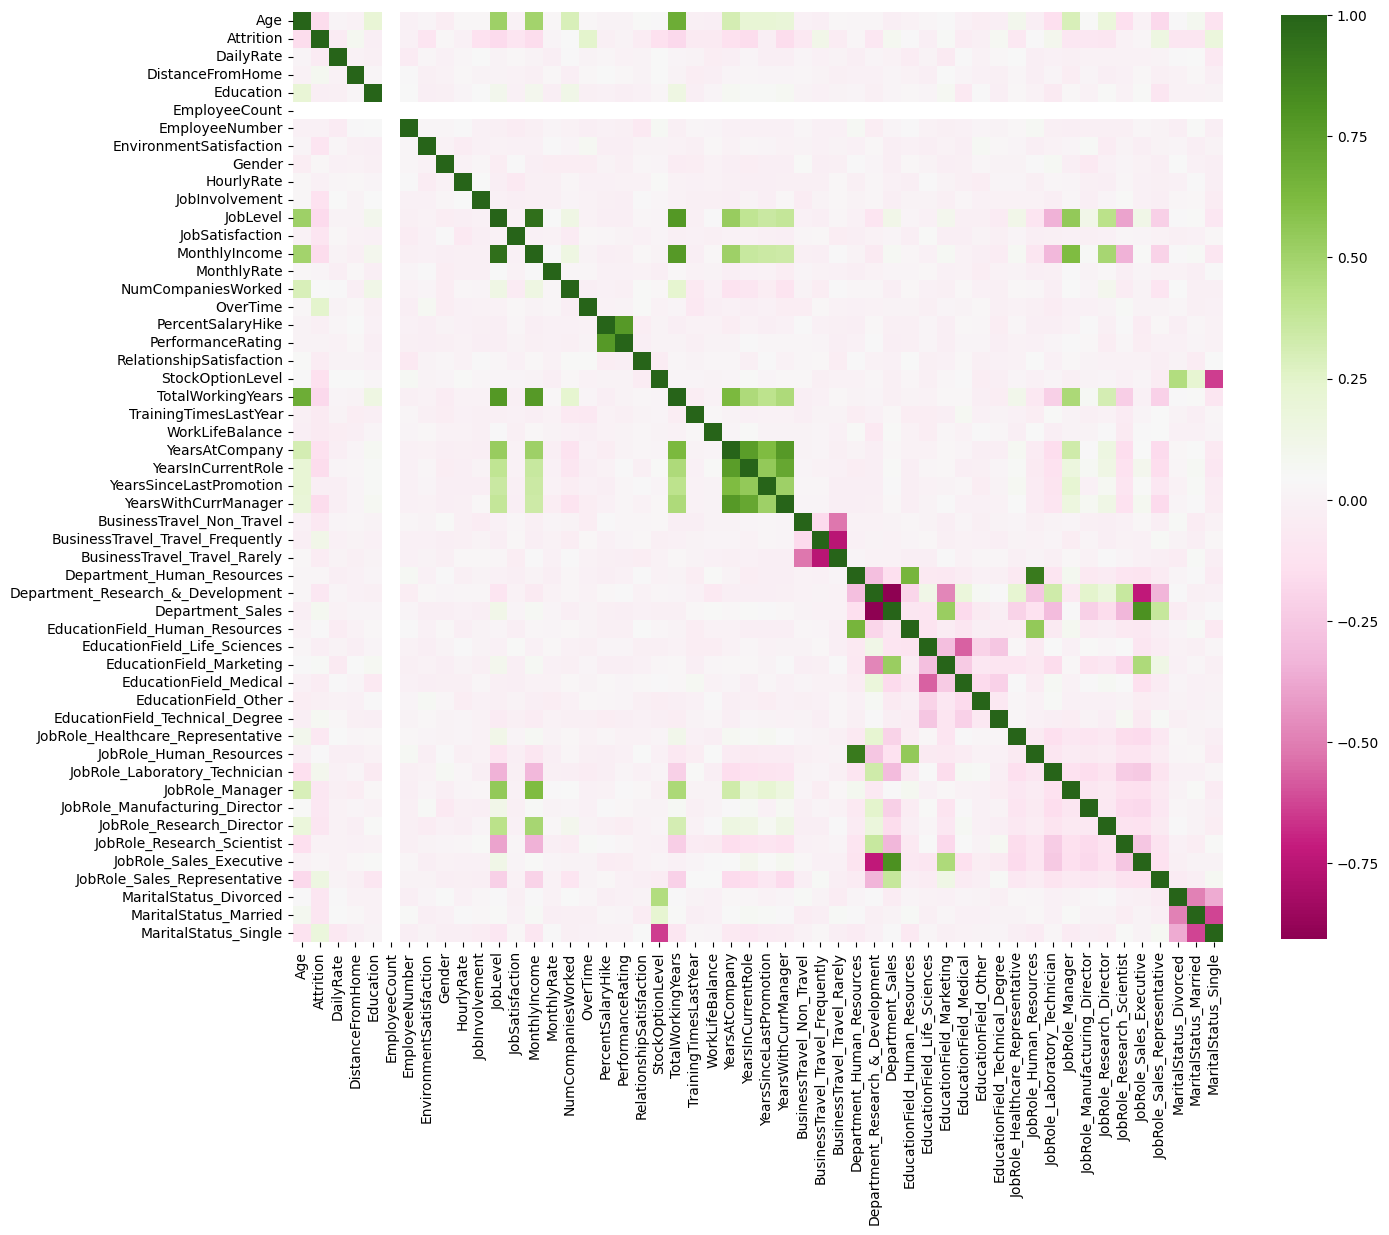

In [ ]:
# Filter the DataFrame to include only numeric columns
t_data_numeric = t_data.select_dtypes(include=['number'])

# Compute the correlation matrix
corr_matrix = t_data_numeric.corr()

# Plot the correlation matrix as a heatmap without annotations
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=False, cmap='PiYG', square=True, cbar_kws={"shrink": 0.8})

# Show the plot
plt.show()

The heatmap may appear overwhelming due to the number of variables, especially in larger datasets, making it more difficult to interpret specific relationships.

To provide a clearer view, the following heatmap focuses specifically on the top 20 variables that have the strongest correlations with the Attrition variable, offering more targeted insights into the factors that could be influencing employee turnover.

Variables that correlate most with Attrition:
Attrition                           1.00
OverTime                            0.25
MaritalStatus_Single                0.18
JobRole_Sales_Representative        0.16
BusinessTravel_Travel_Frequently    0.12
JobRole_Laboratory_Technician       0.10
Department_Sales                    0.08
DistanceFromHome                    0.08
EducationField_Technical_Degree     0.07
EducationField_Marketing            0.06
NumCompaniesWorked                  0.04
EducationField_Human_Resources      0.04
JobRole_Human_Resources             0.04
Gender                              0.03
JobRole_Sales_Executive             0.02
Department_Human_Resources          0.02
MonthlyRate                         0.02
PerformanceRating                   0.00
JobRole_Research_Scientist         -0.00
HourlyRate                         -0.01
Name: Attrition, dtype: float64


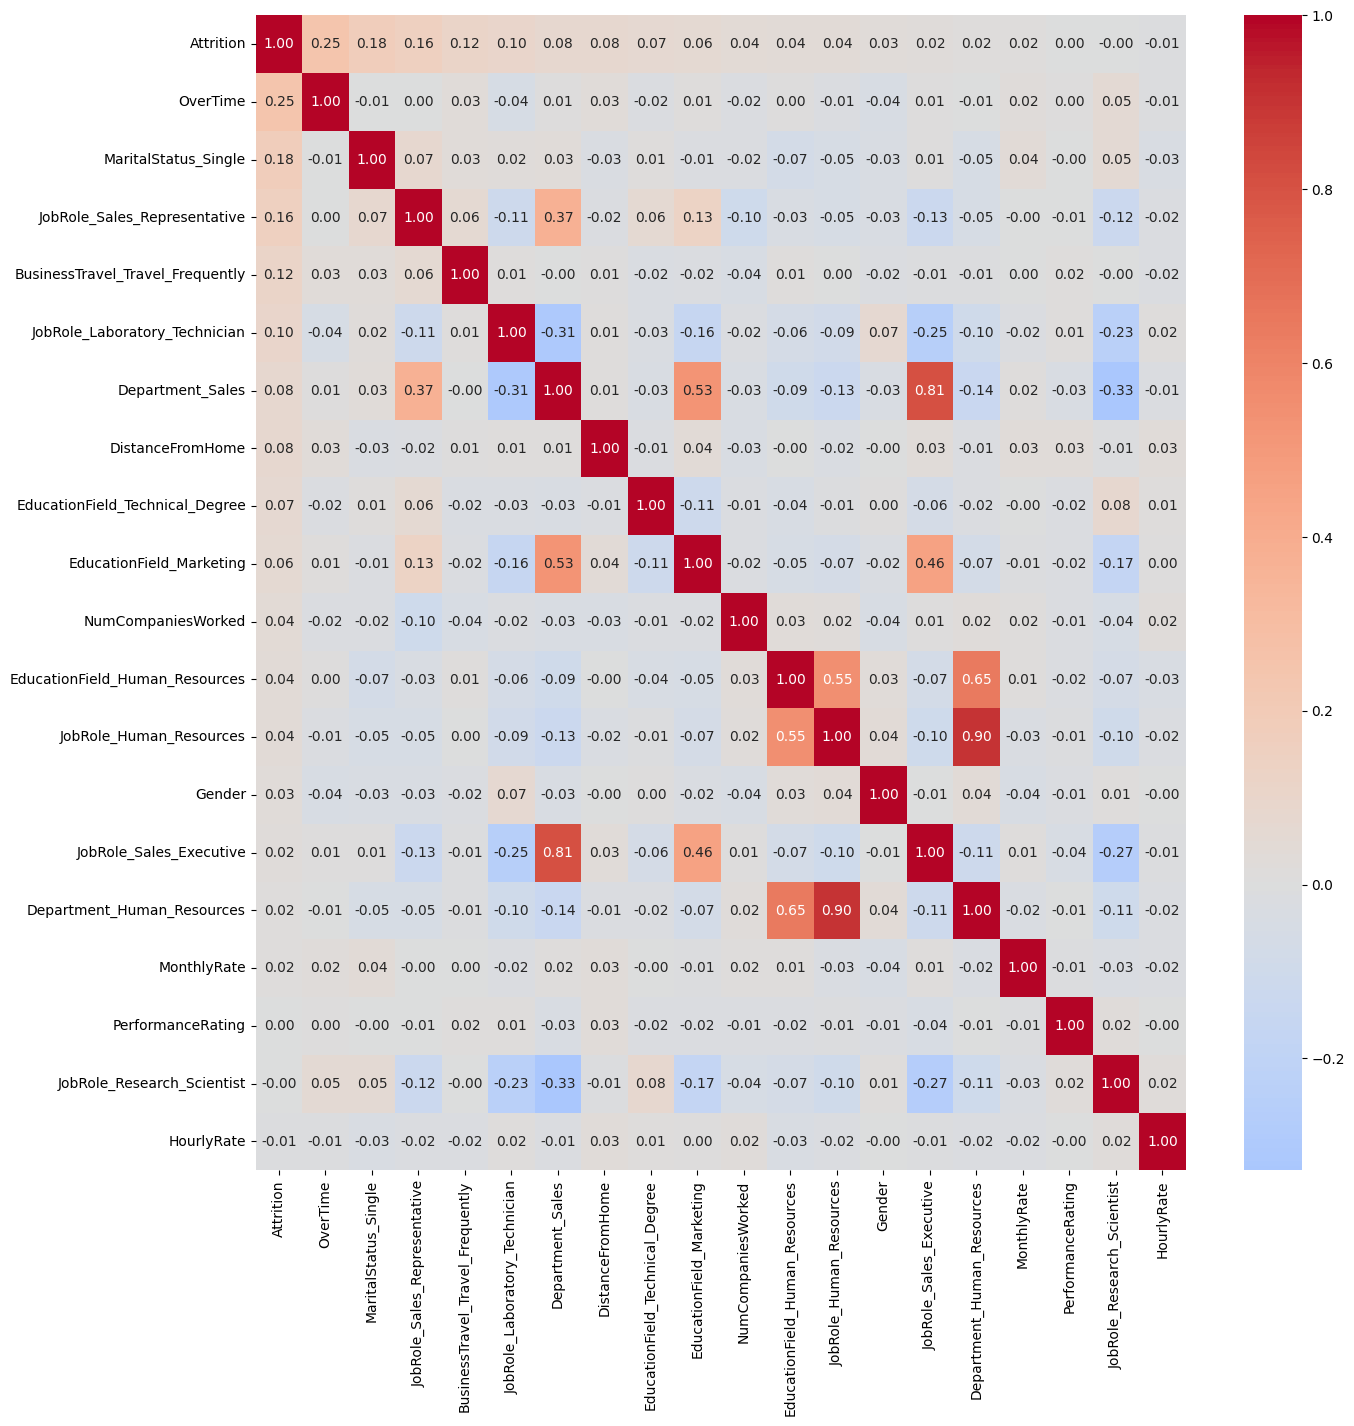

In [ ]:
# Select only numerical columns for correlation analysis
numerical_data = t_data.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix for the numerical DataFrame
corr_matrix = numerical_data.corr()

# Get the top variables that correlate with 'Attrition'
attrition_corr = corr_matrix.nlargest(20, 'Attrition')['Attrition'].index

# Print the correlation values for the selected variables
print("Variables that correlate most with Attrition:")
print(corr_matrix.loc[attrition_corr, 'Attrition'])

# Plot the heatmap for the selected variables with a clearer color palette
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix.loc[attrition_corr, attrition_corr], annot=True, cmap="coolwarm", annot_kws={"size": 10}, center=0, fmt=".2f")

# Show the plot
plt.show()

From the heatmap focusing on the top variables correlated with Attrition, we can observe several key relationships:

* `OverTime` has the strongest positive correlation with Attrition, with a value of **0.25**, indicating that employees who work overtime are more likely to leave.

* `MaritalStatus_Single` follows with a correlation of **0.18**, suggesting that single employees are more prone to attrition compared to their married or divorced counterparts.

* `JobRole_Sales Representative` shows a correlation of **0.16**, implying that sales representatives tend to have higher turnover rates.

* `BusinessTravel_Travel_Frequently` also correlates positively, **0.12**), indicating that employees who frequently travel for business are more likely to leave.

* `JobRole_Laboratory Technician` has a correlation of **0.10**, which, while smaller, still suggests a relationship between this job role and attrition.

Though weaker, correlations like `DistanceFromHome` (0.08) and `EducationField_Technical Degree` (0.07) may still offer useful insights into attrition patterns, particularly when combined with other variables.

Interestingly, some variables, such as `JobRole_Research Scientist` (-0.00) and `HourlyRate` (-0.01), show near-zero or negative correlations, indicating that they have little to no direct impact on employee attrition in this dataset.

## 3.4 Data Visualizations with Attrition

In this section, we will explore a more detailed relationship between employee attrition and several key variables.

By visualizing and comparing these variables with attrition rates, we aim to uncover deeper insights into how factors such as job roles, business travel frequency, marital status, and overtime impact employee turnover. This analysis will be supported by various plots, helping to illustrate and clarify the extent of each variable's influence on attrition within the dataset.

### Attrition

To gain insights into employee turnover, we first examined the counts of the **Attrition** variable, which indicates whether an employee has left the company (1) or not (0).

In [ ]:
# Attrition numbers
t_data['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [ ]:
#  Attrition percentage
(t_data['Attrition'].value_counts()/len(t_data)*100).round(2)

,count
Attrition,
0,83.88
1,16.12


This indicates a relatively average attrition rate.

This suggests that the company might have policies in place to retain its workforce, but there might be room for improvement.

It is to be noted though, that average attrition rates vary across industries and this information cannot be deducted from the data given.

### Age

Age plays a central role in our analysis as it directly relates to one of our core research questions.

 To explore this, we divided employees into two groups based on the median age of 36: those **under 36** and those **36 and older**. This segmentation allows us to assess whether younger employees are more likely to leave the company and to investigate how age influences the prioritization of work-life balance. Understanding these patterns is critical for identifying age-specific retention challenges and developing strategies that cater to the unique needs of both younger and older employees.



In [ ]:
# Divide data into two age groups based on the median age (36)
t_data['AgeGroup'] = t_data['Age'].apply(lambda x: 'Below 36' if x < 36 else '36 and Above')

# Age group counts
age_group_counts = t_data['AgeGroup'].value_counts().reset_index()
age_group_counts.columns = ['AgeGroup', 'Age Group Counts']

# Age group percentages
age_group_percentage = ((age_group_counts['Age Group Counts'] / len(t_data)) * 100).round(2)
age_group_counts['Age Group Percentages (%)'] = age_group_percentage

# Attrition by Age Group (%)
attrition_by_age_group = t_data.groupby('AgeGroup')['Attrition'].mean().reset_index()
attrition_by_age_group.columns = ['AgeGroup', 'Attrition by Age Group (%)']
attrition_by_age_group['Attrition by Age Group (%)'] = (attrition_by_age_group['Attrition by Age Group (%)'] * 100).round(2)

# Merge all the information into a single DataFrame
df_age_analysis = pd.merge(age_group_counts, attrition_by_age_group, on='AgeGroup').set_index('AgeGroup')

# Display the final DataFrame
df_age_analysis

,Age Group Counts,Age Group Percentages (%),Attrition by Age Group (%)
AgeGroup,,,
36 and Above,741,50.41,10.39
Below 36,729,49.59,21.95


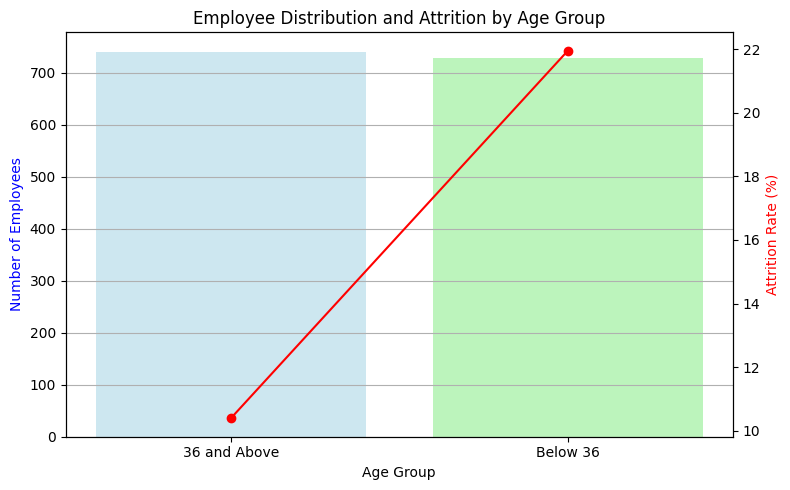

In [ ]:

# Create a grouped bar plot for age group distribution and attrition
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar plot for employee distribution by age group
ax1.bar(df_age_analysis.index, df_age_analysis['Age Group Counts'], color=['lightblue', 'lightgreen'], alpha=0.6, label='Employee Count')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Number of Employees', color='blue')
ax1.set_title('Employee Distribution and Attrition by Age Group')
ax1.grid(axis='y')

# Create a second y-axis to plot attrition rates
ax2 = ax1.twinx()
ax2.plot(df_age_analysis.index, df_age_analysis['Attrition by Age Group (%)'], color='red', marker='o', label='Attrition Rate')
ax2.set_ylabel('Attrition Rate (%)', color='red')

# Adjust the layout and show the plot
fig.tight_layout()
plt.show()

The analysis of age distribution reveals an almost even split in the workforce, with 49.59% of employees under 36 and 50.41% aged 36 and above. This balance provides a mix of generational knowledge and diverse perspectives within the organization.

However, when examining the relationship between age and attrition, a clear trend emerges: **younger employees** under 36 experience significantly higher attrition, of **21.95%**,  compared to those **aged 36 and above**, with **10.39%**. This correlation supports our research question by showing that younger employees are indeed more likely to leave the company. Factors driving this may include their pursuit of career advancement opportunities, dissatisfaction in their early-stage roles, or unmet expectations regarding work-life balance.

Work-life balance now emerges as a critical factor that may influence retention rates across age groups. Younger employees might prioritize flexibility and support in managing their personal and professional lives, and failure to address these needs could further exacerbate their higher attrition rates.


To address these issues, the company should consider implementing retention strategies that prioritize work-life balance for all employees. This could involve offering flexible work arrangements, promoting a healthier balance between professional and personal responsibilities, and providing support systems to manage workload and stress. Additionally, the company could offer professional development opportunities and mentorship programs to foster long-term engagement.



### Work-Life Balance


Building on the insights gained from the analysis of age and its relationship with attrition, work-life balance emerges as another key factor to consider. Our research question specifically explores whether younger employees value work-life balance more than their older counterparts when deciding to leave the company.

Since younger employees exhibit higher attrition rates, it raises the question of whether unmet expectations regarding work-life balance are contributing to this trend. By examining work-life balance in more detail, we can assess whether it plays a pivotal role in employee retention across different age groups and whether younger employees, in particular, are more sensitive to issues surrounding their work-life integration. Understanding this relationship will help refine retention strategies aimed at reducing attrition, especially among the younger segment of the workforce.

In [ ]:
# Work-Life Balance Counts
work_life_balance_counts = t_data['WorkLifeBalance'].value_counts().reindex([1, 2, 3, 4]).reset_index()
work_life_balance_counts.columns = ['WorkLifeBalance', 'Work-Life Balance Counts']

# Fill missing values with 0 for any work-life balance level that doesn't exist in the dataset
work_life_balance_counts.fillna(0, inplace=True)

# Set WorkLifeBalance as the index
work_life_balance_counts.set_index('WorkLifeBalance', inplace=True)

# Work-Life Balance Percentages
work_life_balance_counts['Work-Life Balance Percentages (%)'] = ((work_life_balance_counts['Work-Life Balance Counts'] / len(t_data)) * 100).round(2)

# Attrition by Work-Life Balance (%)
attrition_by_work_life_balance = t_data.groupby('WorkLifeBalance')['Attrition'].mean().reindex([1, 2, 3, 4]).reset_index()
attrition_by_work_life_balance.columns = ['WorkLifeBalance', 'Attrition by Work-Life Balance (%)']
attrition_by_work_life_balance['Attrition by Work-Life Balance (%)'] = (attrition_by_work_life_balance['Attrition by Work-Life Balance (%)'] * 100).round(2)

# Fill missing values with 0 for any work-life balance level that doesn't exist in the dataset
attrition_by_work_life_balance.fillna(0, inplace=True)

# Merge all the information into a single DataFrame
df_work_life_balance_analysis = pd.merge(work_life_balance_counts, attrition_by_work_life_balance, left_index=True, right_on='WorkLifeBalance')
df_work_life_balance_analysis.set_index('WorkLifeBalance', inplace=True)

# Display the final DataFrame
df_work_life_balance_analysis

,Work-Life Balance Counts,Work-Life Balance Percentages (%),Attrition by Work-Life Balance (%)
WorkLifeBalance,,,
1,80,5.44,31.25
2,344,23.40,16.86
3,893,60.75,14.22
4,153,10.41,17.65


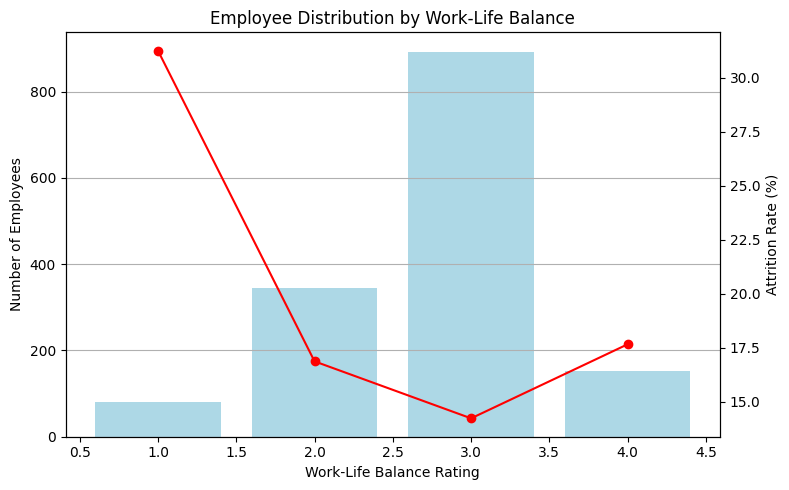

In [ ]:
# Plot for Work-Life Balance Distribution and Attrition
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar plot for Work-Life Balance Counts
ax1.bar(df_work_life_balance_analysis.index, df_work_life_balance_analysis['Work-Life Balance Counts'], color='lightblue', label='Number of Employees')
ax1.set_xlabel('Work-Life Balance Rating')
ax1.set_ylabel('Number of Employees')
ax1.set_title('Employee Distribution by Work-Life Balance')
ax1.grid(axis='y')

# Line plot for Attrition by Work-Life Balance
ax2 = ax1.twinx()
ax2.plot(df_work_life_balance_analysis.index, df_work_life_balance_analysis['Attrition by Work-Life Balance (%)'], color='red', marker='o', label='Attrition Rate (%)')
ax2.set_ylabel('Attrition Rate (%)')

# Show the plot
fig.tight_layout()
plt.show()

The analysis of work-life balance among employees reveals a significant trend in perceptions of this critical factor. A **majority** of employees (60.75%) rated their work-life balance as a **3**, indicating a generally favorable perception. However, a notable portion of the workforce rated their experiences differently: **23.40%** rated it as **2**, **10.41%** rated it as **4**, and **5.44%** expressed considerable dissatisfaction with a rating of **1**.

When examining attrition rates in relation to work-life balance ratings, a concerning pattern emerges. Employees who rated their work-life balance as **1** exhibited the highest attrition rate at **31.25%**, suggesting a strong correlation between poor work-life balance and a heightened likelihood of leaving the organization. Furthermore, those rating their work-life balance as **2** also displayed a substantial attrition rate of **16.86%**. In contrast, employees who rated their work-life balance as **3** and **4** experienced lower attrition rates of **14.22%** and **17.65%**, respectively.

Interestingly, the slight **increase** in attrition for employees with a **rating of 4** may appear counterintuitive, as higher satisfaction typically correlates with lower turnover. This phenomenon could be attributed to several factors. Employees who rate their work-life balance as 4 might feel confident in their skills and seek better opportunities or new challenges elsewhere. They may also feel empowered to pursue other career paths, leading to proactive job search behavior that increases turnover within this group.

These findings underscore the critical importance of work-life balance in employee retention. Employees with lower ratings are at a significantly greater risk of attrition, highlighting the need for organizations to implement strategies aimed at enhancing work-life balance. Initiatives such as flexible working arrangements, mental health support, and effective workload management could prove vital in improving employee satisfaction and retention rates. By prioritizing work-life balance, organizations can foster a more supportive environment that ultimately reduces turnover and promotes a more engaged workforce.



Before diving into the individual analysis of variables related to work-life balance, it's important to understand the broader context of how these factors influence employee satisfaction and attrition. Work-life balance is not an isolated metric; it is shaped by various job-related aspects such as satisfaction with one's role, level of involvement in daily tasks, job position, salary progression, and even work conditions like overtime and travel demands. Each of these variables can directly impact how employees perceive the balance between their personal and professional lives, ultimately affecting their decision to stay or leave the company.

In our research, we aim to investigate how these variables, when intertwined with work-life balance, influence employee attrition. By examining factors such as job satisfaction, job involvement, job level, percent of salary hike, business travel, department, overtime, and marital status, we can gain deeper insights into the specific drivers of turnover. These elements may provide crucial clues about why certain employees—particularly younger ones—are more likely to leave, aligning with our broader research question about the role of age and work-life balance in employee attrition.

In the following sections, we will explore each of these variables in detail, analyzing their relationships to work-life balance and how they contribute to employee retention or attrition within the company.

### Job Satisfaction

Job satisfaction is a vital component of employee engagement and a key indicator of overall organizational well-being. It represents how employees perceive their roles, responsibilities, and work environment. When job satisfaction is high, it often translates into enhanced productivity, stronger collaboration among teams, and significantly lower turnover rates. Satisfied employees are more likely to stay committed to the organization, contributing positively to its success, while low job satisfaction can lead to disengagement and increased attrition.

In [ ]:
# Job Satisfaction counts
job_satisfaction_counts = t_data['JobSatisfaction'].value_counts().reindex([1, 2, 3, 4]).reset_index()
job_satisfaction_counts.columns = ['JobSatisfaction', 'Job Satisfaction Counts']

# Fill missing values with 0 for any job satisfaction level that doesn't exist in the dataset
job_satisfaction_counts.fillna(0, inplace=True)

# Set JobSatisfaction as the index
job_satisfaction_counts.set_index('JobSatisfaction', inplace=True)

# Attrition by Job Satisfaction (%)
attrition_by_job_satisfaction = t_data.groupby('JobSatisfaction')['Attrition'].mean().reindex([1, 2, 3, 4]).reset_index()
attrition_by_job_satisfaction.columns = ['JobSatisfaction', 'Attrition by Job Satisfaction (%)']
attrition_by_job_satisfaction['Attrition by Job Satisfaction (%)'] = (attrition_by_job_satisfaction['Attrition by Job Satisfaction (%)'] * 100).round(2)

# Fill missing values with 0 for any job satisfaction level that doesn't exist in the dataset
attrition_by_job_satisfaction.fillna(0, inplace=True)

# Merge all the information into a single DataFrame
df_job_satisfaction_analysis = pd.merge(job_satisfaction_counts, attrition_by_job_satisfaction, left_index=True, right_on='JobSatisfaction')
df_job_satisfaction_analysis.set_index('JobSatisfaction', inplace=True)

# Display the final DataFrame
df_job_satisfaction_analysis

,Job Satisfaction Counts,Attrition by Job Satisfaction (%)
JobSatisfaction,,
1,289,22.84
2,280,16.43
3,442,16.52
4,459,11.33


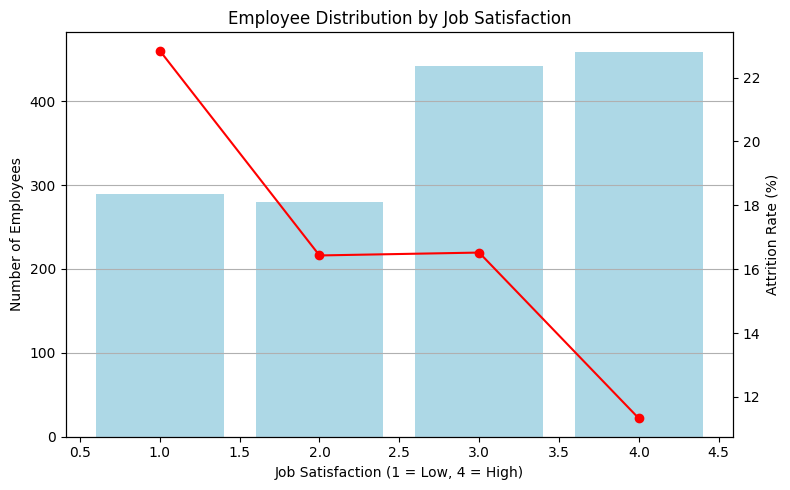

In [ ]:
# Plot for Job Satisfaction Distribution and Attrition
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar plot for Job Satisfaction counts
ax1.bar(df_job_satisfaction_analysis.index, df_job_satisfaction_analysis['Job Satisfaction Counts'], color='lightblue', label='Number of Employees')
ax1.set_xlabel('Job Satisfaction (1 = Low, 4 = High)')
ax1.set_ylabel('Number of Employees')
ax1.set_title('Employee Distribution by Job Satisfaction')
ax1.grid(axis='y')

# Line plot for Attrition by Job Satisfaction
ax2 = ax1.twinx()
ax2.plot(df_job_satisfaction_analysis.index, df_job_satisfaction_analysis['Attrition by Job Satisfaction (%)'], color='red', marker='o', label='Attrition Rate (%)')
ax2.set_ylabel('Attrition Rate (%)')

# Show the plot
fig.tight_layout()
plt.show()

The analysis reveals a strong correlation between job satisfaction and attrition rates.

The **majority** of employees report **high satisfaction**, with 459 employees rating their satisfaction at level 4 and 442 at level 3. On the other hand, fewer employees fall into the lower satisfaction categories, with 289 at level 1 and 280 at level 2.

Attrition rates are significantly higher among those with low job satisfaction. Employees with a satisfaction rating of **1** exhibit an alarming attrition rate of **22.84%**, signaling serious retention issues. Similarly, attrition rates for those rating their satisfaction as 2 and 3 remain elevated at 16.43% and 16.52%, respectively. In contrast, employees who report the highest job satisfaction, **level 4**, experience a much lower attrition rate of **11.33%**.

These findings underscore the critical role of job satisfaction in employee retention. Lower satisfaction levels are closely linked to higher attrition, emphasizing the need to address employee concerns and create a more positive work environment to reduce turnover.

### Job Involvement

Job involvement reflects the extent to which employees identify with their work and view it as a vital part of their self-concept. High levels of job involvement often result in greater job satisfaction, enhanced productivity, and reduced turnover, as employees who are deeply engaged in their roles are more likely to stay committed to the organization.

In [ ]:
# Job Involvement counts
job_involvement_counts = t_data['JobInvolvement'].value_counts().reindex([1, 2, 3, 4]).reset_index()
job_involvement_counts.columns = ['JobInvolvement', 'Job Involvement Counts']

# Fill missing values with 0 for any job involvement level that doesn't exist in the dataset
job_involvement_counts.fillna(0, inplace=True)

# Set JobInvolvement as the index
job_involvement_counts.set_index('JobInvolvement', inplace=True)

# Attrition by Job Involvement (%)
attrition_by_job_involvement = t_data.groupby('JobInvolvement')['Attrition'].mean().reindex([1, 2, 3, 4]).reset_index()
attrition_by_job_involvement.columns = ['JobInvolvement', 'Attrition by Job Involvement (%)']
attrition_by_job_involvement['Attrition by Job Involvement (%)'] = (attrition_by_job_involvement['Attrition by Job Involvement (%)'] * 100).round(2)

# Fill missing values with 0 for any job involvement level that doesn't exist in the dataset
attrition_by_job_involvement.fillna(0, inplace=True)

# Merge all the information into a single DataFrame
df_job_involvement_analysis = pd.merge(job_involvement_counts, attrition_by_job_involvement, left_index=True, right_on='JobInvolvement')
df_job_involvement_analysis.set_index('JobInvolvement', inplace=True)

# Display the final DataFrame
df_job_involvement_analysis


,Job Involvement Counts,Attrition by Job Involvement (%)
JobInvolvement,,
1,83,33.73
2,375,18.93
3,868,14.40
4,144,9.03


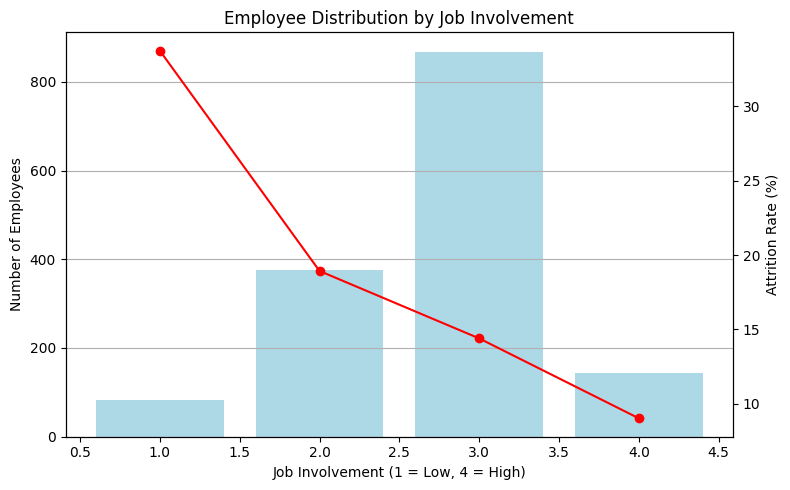

In [ ]:
# Job Involvement counts
job_involvement_counts = t_data['JobInvolvement'].value_counts().reindex([1, 2, 3, 4]).reset_index()
job_involvement_counts.columns = ['JobInvolvement', 'Job Involvement Counts']

# Fill missing values with 0 for any job involvement level that doesn't exist in the dataset
job_involvement_counts.fillna(0, inplace=True)

# Set JobInvolvement as the index
job_involvement_counts.set_index('JobInvolvement', inplace=True)

# Attrition by Job Involvement (%)
attrition_by_job_involvement = t_data.groupby('JobInvolvement')['Attrition'].mean().reindex([1, 2, 3, 4]).reset_index()
attrition_by_job_involvement.columns = ['JobInvolvement', 'Attrition by Job Involvement (%)']
attrition_by_job_involvement['Attrition by Job Involvement (%)'] = (attrition_by_job_involvement['Attrition by Job Involvement (%)'] * 100).round(2)

# Fill missing values with 0 for any job involvement level that doesn't exist in the dataset
attrition_by_job_involvement.fillna(0, inplace=True)

# Merge all the information into a single DataFrame
df_job_involvement_analysis = pd.merge(job_involvement_counts, attrition_by_job_involvement, left_index=True, right_on='JobInvolvement')
df_job_involvement_analysis.set_index('JobInvolvement', inplace=True)

# Display the final DataFrame
df_job_involvement_analysis

# Plot for Job Involvement Distribution and Attrition
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar plot for Job Involvement counts
ax1.bar(df_job_involvement_analysis.index, df_job_involvement_analysis['Job Involvement Counts'], color='lightblue', label='Number of Employees')
ax1.set_xlabel('Job Involvement (1 = Low, 4 = High)')
ax1.set_ylabel('Number of Employees')
ax1.set_title('Employee Distribution by Job Involvement')
ax1.grid(axis='y')

# Line plot for Attrition by Job Involvement
ax2 = ax1.twinx()
ax2.plot(df_job_involvement_analysis.index, df_job_involvement_analysis['Attrition by Job Involvement (%)'], color='red', marker='o', label='Attrition Rate (%)')
ax2.set_ylabel('Attrition Rate (%)')

# Show the plot
fig.tight_layout()
plt.show()


**Similar to job satisfaction**, the analysis of job involvement among employees shows a clear link between involvement levels and attrition rates.

The majority of employees (**868**) report a **moderate level of job involvement**, rating it as 3. A significant portion, however, reports **lower involvement levels**, with **375 employees rating it as 2**, while smaller groups rate it as 1 (**83 employees**) or 4 (**144 employees**). This distribution indicates that while many employees feel moderately involved in their work, there remains a notable group with **lower involvement**, which could signal disengagement.

Attrition rates underscore a **concerning pattern**, particularly among employees with **low job involvement**. Those who rate their involvement as **1 face the highest attrition rate at 33.73%**, signaling a strong correlation between low engagement and turnover. Similarly, employees rating their involvement as **2 have an attrition rate of 18.93%**. As job involvement increases, attrition rates decline significantly, with employees rating it as **3 showing a 14.40% attrition rate** and those rating it as **4 having the lowest rate at 9.03%**.

These findings highlight the importance of fostering **greater job involvement** to enhance employee retention. Organizations can implement strategies such as **promoting participation in decision-making processes**, recognizing individual contributions, and creating opportunities for employees to take ownership of their work. By boosting job involvement, companies can cultivate a **more engaged workforce** and **reduce turnover rates**.


### Job Level

Job level within an organization significantly shapes employees' experiences, influencing their responsibilities, engagement, and career outlook. Higher job levels often come with increased autonomy, decision-making power, and opportunities for growth, which can directly impact satisfaction and retention. By examining the relationship between job level and attrition, organizations can gain valuable insights into how hierarchical position affects turnover, allowing them to develop more targeted retention strategies and foster a more committed and motivated workforce.

In [ ]:
# Job Level counts
job_level_counts = t_data['JobLevel'].value_counts().reindex([1, 2, 3, 4, 5]).reset_index()
job_level_counts.columns = ['JobLevel', 'Job Level Counts']

# Fill missing values with 0 for any job level that doesn't exist in the dataset
job_level_counts.fillna(0, inplace=True)

# Set JobLevel as the index
job_level_counts.set_index('JobLevel', inplace=True)

# Attrition by Job Level (%)
attrition_by_job_level = t_data.groupby('JobLevel')['Attrition'].mean().reindex([1, 2, 3, 4, 5]).reset_index()
attrition_by_job_level.columns = ['JobLevel', 'Attrition by Job Level (%)']
attrition_by_job_level['Attrition by Job Level (%)'] = (attrition_by_job_level['Attrition by Job Level (%)'] * 100).round(2)

# Fill missing values with 0 for any job level that doesn't exist in the dataset
attrition_by_job_level.fillna(0, inplace=True)

# Merge all the information into a single DataFrame
df_job_level_analysis = pd.merge(job_level_counts, attrition_by_job_level, left_index=True, right_on='JobLevel')
df_job_level_analysis.set_index('JobLevel', inplace=True)

# Display the final DataFrame
df_job_level_analysis

,Job Level Counts,Attrition by Job Level (%)
JobLevel,,
1,543,26.34
2,534,9.74
3,218,14.68
4,106,4.72
5,69,7.25


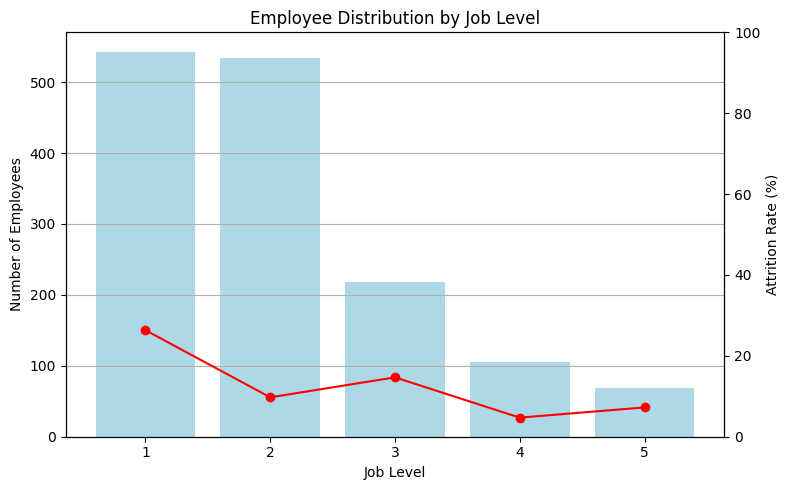

In [ ]:
# Plot for Job Level Distribution and Attrition
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar plot for Job Level counts
ax1.bar(df_job_level_analysis.index, df_job_level_analysis['Job Level Counts'], color='lightblue', label='Number of Employees')
ax1.set_xlabel('Job Level')
ax1.set_ylabel('Number of Employees')
ax1.set_title('Employee Distribution by Job Level')
ax1.grid(axis='y')

# Line plot for Attrition by Job Level
ax2 = ax1.twinx()
ax2.plot(df_job_level_analysis.index, df_job_level_analysis['Attrition by Job Level (%)'], color='red', marker='o', label='Attrition Rate (%)')
ax2.set_ylabel('Attrition Rate (%)')

# Set limits for better visibility
ax2.set_ylim(0, 100)  # Ensure the y-axis for attrition goes from 0 to 100%

# Align x-axis ticks with Job Levels
ax1.set_xticks(df_job_level_analysis.index)

# Show the plot
fig.tight_layout()
plt.show()


The analysis reveals that the majority of employees are fairly evenly distributed across **Job Levels 1 and 2**, with counts of **543** and **534**, respectively. In contrast, there are fewer employees at higher levels, with **Job Level 3** having **218**, **Job Level 4** having **106**, and **Job Level 5** having **69** employees. This distribution reflects a typical organizational structure, where **entry-level** and **mid-level positions** are more prevalent.

The **attrition rates** reveal notable patterns across job levels. **Entry-level employees (Job Level 1)** experience a high attrition rate of **26.34%**, suggesting that new hires may struggle with integration or job satisfaction. Meanwhile, **employees at Job Level 2** show a significantly lower attrition rate of **9.74%**, indicating they have likely found a better fit within the organization compared to their entry-level counterparts.

However, the attrition rate increases again for **Job Level 3**, reaching **14.68%**. This suggests that while this level may be viewed as a stepping stone to higher positions, it also presents challenges that could contribute to turnover, such as increased job expectations, limited growth opportunities, or dissatisfaction with management.

Interestingly, employees at **Job Level 5** exhibit an attrition rate of **7.25%**. Although this rate is lower than that of Job Level 3, it remains concerning given that this level typically comprises senior roles where retention is expected to be higher due to employees’ vested interests in the organization. The elevated attrition rate at this level may be influenced by factors such as retirement, career transitions, or attractive opportunities elsewhere.

These findings highlight the critical need for targeted retention strategies, particularly for **entry-level** and **mid-level employees**, who are predominantly younger individuals. Organizations should concentrate on enhancing the **onboarding process** and providing **career development opportunities** for employees at Job Levels 3 and 5. By addressing the unique concerns of employees across different job levels, organizations can foster a more engaged, satisfied, and stable workforce.


### Percent of Salary Hike

Understanding the impact of salary increments on employee retention is essential for organizations. The PercentSalaryHike variable indicates the percentage increase in an employee’s salary, serving as a critical factor that can significantly influence job satisfaction and motivation. By effectively managing salary increments, companies can enhance employee engagement and loyalty, ultimately shaping their decision to stay with the organization.

In [ ]:
# Percent Salary Hike counts
salary_hike_counts = t_data['PercentSalaryHike'].value_counts().sort_index().reset_index()
salary_hike_counts.columns = ['PercentSalaryHike', 'Percent Salary Hike Counts']

# Attrition by Percent Salary Hike (%)
attrition_by_salary_hike = t_data.groupby('PercentSalaryHike')['Attrition'].mean().reset_index()
attrition_by_salary_hike.columns = ['PercentSalaryHike', 'Attrition by Percent Salary Hike (%)']
attrition_by_salary_hike['Attrition by Percent Salary Hike (%)'] = attrition_by_salary_hike['Attrition by Percent Salary Hike (%)'].round(2)

# Merge all the information into a single DataFrame
df_salary_hike_analysis = pd.merge(salary_hike_counts, attrition_by_salary_hike, on='PercentSalaryHike').set_index('PercentSalaryHike')
df_salary_hike_analysis.index.name = 'Percent Salary Hike'  # Set the index name explicitly

# Display the final DataFrame
df_salary_hike_analysis


,Percent Salary Hike Counts,Attrition by Percent Salary Hike (%)
Percent Salary Hike,,
11,210,0.20
12,198,0.17
13,209,0.16
14,201,0.12
15,101,0.18
16,78,0.18
17,82,0.17
18,89,0.15
19,76,0.12


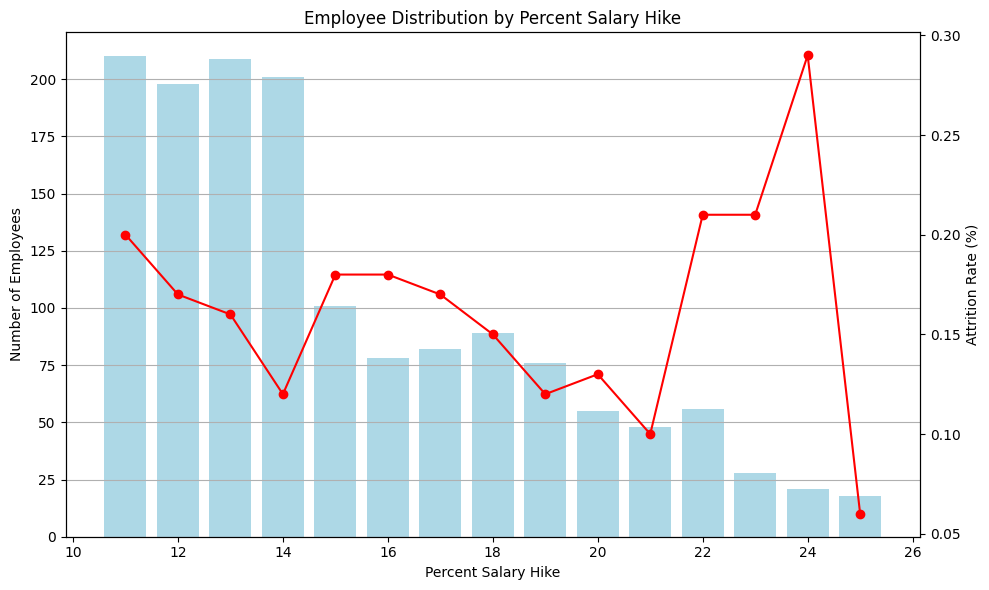

In [ ]:
# Plot for Percent Salary Hike Distribution and Attrition
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Percent Salary Hike counts
ax1.bar(df_salary_hike_analysis.index, df_salary_hike_analysis['Percent Salary Hike Counts'], color='lightblue', label='Number of Employees')
ax1.set_xlabel('Percent Salary Hike')
ax1.set_ylabel('Number of Employees')
ax1.set_title('Employee Distribution by Percent Salary Hike')
ax1.grid(axis='y')

# Line plot for Attrition by Percent Salary Hike
ax2 = ax1.twinx()
ax2.plot(df_salary_hike_analysis.index, df_salary_hike_analysis['Attrition by Percent Salary Hike (%)'], color='red', marker='o', label='Attrition Rate (%)')
ax2.set_ylabel('Attrition Rate (%)')

# Show the plot
fig.tight_layout()
plt.show()

The distribution of salary hikes indicates that most employees received increments ranging from 11% to 15%, with 210 employees receiving an 11% hike and 198 receiving a 12% hike. However, as the percentage of salary increases, the number of employees receiving those increments diminishes, particularly at the higher end of the scale, where counts drop significantly for hikes between 23% and 25%.

The attrition rates generally demonstrate a pattern where moderate salary hikes (approximately 11% to 14%) correlate with relatively higher attrition rates, which tend to decrease as salary increments increase. Nevertheless, this trend is disrupted at certain salary hike levels:

- **15% to 16% Salary Hikes:** Attrition rates slightly rise within this range, with 17.82% for those receiving a 15% hike and 17.95% for a 16% hike, suggesting possible dissatisfaction despite the increases.

- **21% Salary Hike:** Employees receiving a 21% salary hike exhibit an attrition rate of only 10.42%, one of the lowest observed, indicating that substantial hikes around this level effectively retain employees.

Additionally, some anomalies disrupt this general pattern:

- **22% and 23% Salary Hikes:** Both show increased attrition rates of 21.43%, which may indicate dissatisfaction or unrealistic expectations tied to these increments. Employees receiving these hikes might feel their contributions are not sufficiently recognized, contributing to higher turnover.

- **24% Salary Hike:** Here, the attrition rate spikes to 28.57%, potentially signaling a significant issue. Employees receiving this increment might perceive it as a token gesture rather than a genuine acknowledgment of their efforts. This may also attract employees who are already contemplating leaving for better opportunities.

- **25% Salary Hike:** Interestingly, the attrition rate drops to 5.56%, suggesting that the highest increment can stabilize retention by addressing prior employee concerns and compensating for earlier dissatisfaction.

These findings underscore the importance of salary hikes in shaping employee retention. The general trend indicates that higher salary increases correlate with lower attrition rates. However, the anomalies observed at certain hike levels highlight the necessity for organizations to ensure that increments are viewed as fair and meaningful. By understanding these dynamics, companies can refine their salary strategies to align more closely with employee expectations, ultimately fostering a more engaged and satisfied workforce.
Additonally, it has to be stated that while there seems to be a trend in this data and the salary hike and attrition rates seem to be correlated, futher investigation would be needed to solidify it being a causality as well.


### Business Travel

Business travel plays a critical role in shaping employee job satisfaction and attrition rates. While travel can provide valuable opportunities for professional development and networking, frequent travel often imposes significant demands on employees. These demands may lead to increased stress and work-life balance challenges, ultimately influencing their overall job satisfaction and decision to remain with the organization. Understanding this relationship is essential for companies looking to enhance employee well-being and reduce turnover.

In [ ]:
# Count of employees based on business travel type
business_travel_counts = t_data[['BusinessTravel_Non_Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely']].sum().reset_index()
business_travel_counts.columns = ['BusinessTravelType', 'Business Travel Counts']

# Total counts for each business travel category
business_travel_counts_percentage = ((business_travel_counts['Business Travel Counts'] / len(t_data)) * 100).round(2)
business_travel_counts['Business Travel Percentage (%)'] = business_travel_counts_percentage

# Creating a new column to identify the business travel category for each employee
t_data['Business_Travel_Category'] = t_data[['BusinessTravel_Non_Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely']].idxmax(axis=1)

# Calculate attrition for each business travel category
business_travel_attrition = t_data.groupby('Business_Travel_Category')['Attrition'].mean().reset_index()
business_travel_attrition.columns = ['BusinessTravelType', 'Attrition by Business Travel Type (%)']
business_travel_attrition['Attrition by Business Travel Type (%)'] = (business_travel_attrition['Attrition by Business Travel Type (%)'] * 100).round(2)

# Merge all the information into a single DataFrame
df_business_travel_analysis = pd.merge(business_travel_counts, business_travel_attrition, on='BusinessTravelType').set_index('BusinessTravelType')

# Display the final DataFrame
df_business_travel_analysis


,Business Travel Counts,Business Travel Percentage (%),Attrition by Business Travel Type (%)
BusinessTravelType,,,
BusinessTravel_Non_Travel,150,10.20,8.00
BusinessTravel_Travel_Frequently,277,18.84,24.91
BusinessTravel_Travel_Rarely,1043,70.95,14.96


<Figure size 1000x600 with 0 Axes>

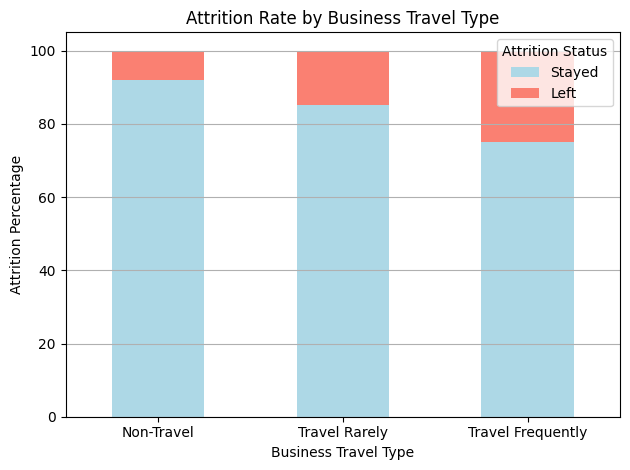

In [ ]:
# Calculate attrition counts by business travel type
attrition_counts = t_data.groupby('Business_Travel_Category')['Attrition'].value_counts().unstack().fillna(0)

# Reorder the index to match the desired order
attrition_counts = attrition_counts.reindex(['BusinessTravel_Non_Travel', 'BusinessTravel_Travel_Rarely', 'BusinessTravel_Travel_Frequently'])

# Calculate attrition percentages
attrition_percentage = attrition_counts.div(attrition_counts.sum(axis=1), axis=0) * 100

# Plotting
plt.figure(figsize=(10, 6))
attrition_percentage.plot(kind='bar', stacked=True, color=['lightblue', 'salmon'])
plt.title('Attrition Rate by Business Travel Type')
plt.xlabel('Business Travel Type')
plt.ylabel('Attrition Percentage')
plt.xticks(rotation=0)

# Set custom x-axis labels
plt.xticks(ticks=range(len(attrition_percentage.index)), labels=['Non-Travel', 'Travel Rarely', 'Travel Frequently'])

plt.legend(title='Attrition Status', labels=['Stayed', 'Left'], loc='upper right')
plt.grid(axis='y')

plt.tight_layout()
plt.show()  # Ensure show() is called as a function


The **distribution of employees** based on their business travel frequency reveals significant insights into employee dynamics. A substantial majority, **70.95%**, travel rarely, while **18.84%** travel frequently, and **10.20%** do not travel at all. This distribution indicates that most employees face minimal travel demands in their roles.

**Attrition rates** across the different business travel categories highlight important trends in employee retention:

- **Non-Traveling Employees:** Those who do not travel for work exhibit the **lowest attrition rate at 8.00%**. This suggests a higher level of job satisfaction and stability among these employees, indicating that a lack of travel may contribute positively to retention.

- **Rare Travelers:** Employees who travel rarely show a **moderate attrition rate of 14.96%**. While they may encounter occasional travel-related challenges, these appear to have a less pronounced impact on their overall job satisfaction compared to frequent travelers.

- **Frequent Travelers:** Conversely, employees who travel frequently experience the **highest attrition rate at 24.91%**. This trend indicates that frequent travel may lead to job dissatisfaction, likely due to factors such as increased workload, extended time away from home, or the inherent stress associated with regular travel commitments.

Overall, the analysis clearly demonstrates that **frequent travelers** are at a heightened risk of attrition relative to their counterparts who travel rarely or not at all. The stress and dissatisfaction associated with frequent travel likely contribute to higher turnover rates. Organizations should prioritize support for employees who travel often, implementing measures such as additional compensation, flexible working arrangements, or initiatives aimed at alleviating travel-related burdens. By addressing these challenges, companies can enhance employee satisfaction and effectively reduce attrition.


### Department

Analyzing the distribution of employees across departments provides valuable insights into workforce allocation and potential attrition factors. By examining the employee counts within each department, we can identify trends associated with attrition rates. This understanding enables management to make informed decisions regarding resource allocation and develop targeted interventions aimed at enhancing employee retention.



In [ ]:
# Calculate department counts by summing up the one-hot encoded columns
department_counts = t_data[['Department_Human_Resources', 'Department_Research_&_Development', 'Department_Sales']].sum().reset_index()
department_counts.columns = ['Department', 'Department Counts']

# Calculate department percentages
department_counts['Department Percentage (%)'] = (department_counts['Department Counts'] / len(t_data) * 100).round(2)

# Calculate attrition by department
t_data['Department'] = t_data[['Department_Human_Resources', 'Department_Research_&_Development', 'Department_Sales']].idxmax(axis=1)
attrition_by_department = t_data.groupby('Department')['Attrition'].mean().reset_index()
attrition_by_department.columns = ['Department', 'Attrition by Department (%)']
attrition_by_department['Attrition by Department (%)'] = (attrition_by_department['Attrition by Department (%)'] * 100).round(2)

# Merge all the information into a single DataFrame
df_department_analysis = pd.merge(department_counts, attrition_by_department, on='Department').set_index('Department')

# Display the final DataFrame
df_department_analysis


,Department Counts,Department Percentage (%),Attrition by Department (%)
Department,,,
Department_Human_Resources,63,4.29,19.05
Department_Research_&_Development,961,65.37,13.84
Department_Sales,446,30.34,20.63


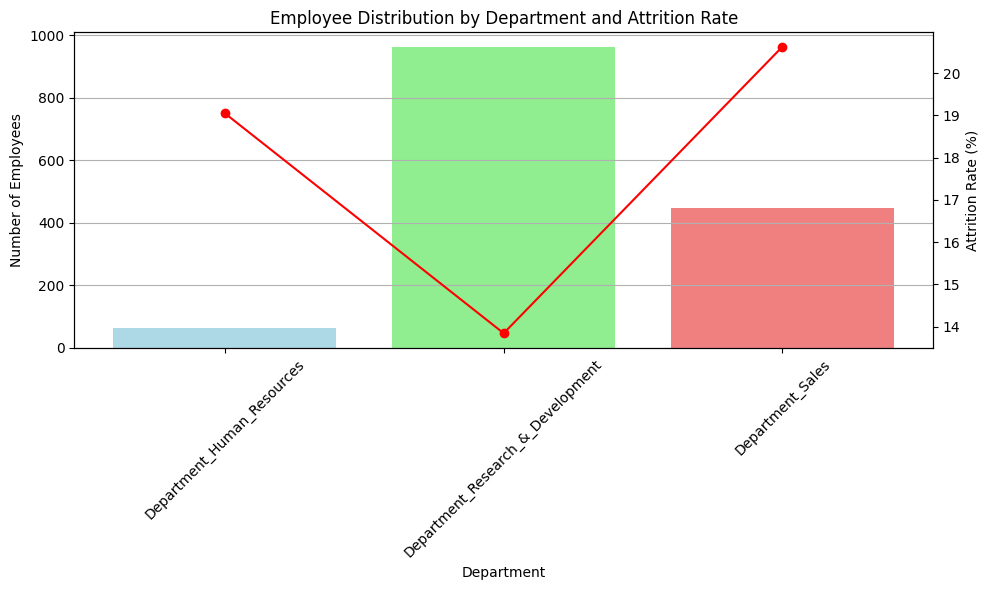

In [ ]:
# Create a grouped bar plot for department distribution and attrition
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for employee distribution
ax1.bar(df_department_analysis.index, df_department_analysis['Department Counts'], color=['lightblue', 'lightgreen', 'lightcoral'], label='Employee Count')
ax1.set_xlabel('Department')
ax1.set_ylabel('Number of Employees')
ax1.set_title('Employee Distribution by Department and Attrition Rate')
ax1.set_xticks(range(len(df_department_analysis.index)))
ax1.set_xticklabels(df_department_analysis.index, rotation=45)
ax1.grid(axis='y')

# Create a second y-axis to plot attrition rates
ax2 = ax1.twinx()
ax2.plot(df_department_analysis.index, df_department_analysis['Attrition by Department (%)'], color='red', marker='o', label='Attrition Rate')
ax2.set_ylabel('Attrition Rate (%)')

# Show the plot
fig.tight_layout()
plt.show()

The distribution of employees reveals that the majority are concentrated in the Research & Development (R&D) department, with smaller proportions in Sales and Human Resources (HR).

Analyzing attrition rates across departments uncovers notable trends that indicate areas requiring focused retention efforts:

* **Sales:** The Sales department exhibits the highest attrition rate at **20.63%**, highlighting retention challenges that may stem from factors such as high pressure, competitive environments, or target-driven roles.

* **Research & Development:** Although the R&D department comprises the largest employee group, it has a moderate attrition rate of **13.84%**. While this rate is lower than that of Sales, it still represents a significant loss of talent, warranting close monitoring due to the department's critical role within the organization.

* **Human Resources:** Despite being the smallest department, HR faces an attrition rate of **19.05%**. This illustrates that smaller teams can experience substantial turnover, which can have a more pronounced impact on operations due to their limited headcount.

Overall, the analysis indicates that attrition is particularly high in the Sales department, suggesting the need for targeted interventions to enhance employee retention. While Research & Development benefits from a larger workforce, it still faces challenges related to moderate turnover. Meanwhile, Human Resources, despite its size, shows a significant turnover percentage that can considerably affect departmental effectiveness. These insights emphasize the necessity for department-specific retention strategies to address the unique challenges each area encounters.

### Overtime

Investigating the relationship between overtime and employee attrition is essential for understanding how workload affects retention rates. Employees who frequently work overtime may encounter elevated stress levels, burnout, and job dissatisfaction, all of which can contribute to higher attrition rates. By examining this relationship, organizations can identify potential areas of concern and implement strategies to mitigate the negative impacts of excessive workload on employee well-being and retention.

In [ ]:
# Count of employees working overtime and not working overtime
overtime_counts = t_data['OverTime'].value_counts().reset_index()
overtime_counts.columns = ['Overtime Status', 'Overtime Counts']

# Calculate percentage of employees working and not working overtime
overtime_counts['Overtime Percentage (%)'] = (overtime_counts['Overtime Counts'] / len(t_data) * 100).round(2)

# Calculate attrition rates for employees working overtime vs. not working overtime
overtime_attrition = t_data.groupby('OverTime')['Attrition'].mean().reset_index()
overtime_attrition.columns = ['Overtime Status', 'Attrition by Overtime (%)']
overtime_attrition['Attrition by Overtime (%)'] = (overtime_attrition['Attrition by Overtime (%)'] * 100).round(2)

# Merge all the information into a single DataFrame
df_overtime_analysis = pd.merge(overtime_counts, overtime_attrition, on='Overtime Status').set_index('Overtime Status')

# Display the final DataFrame
df_overtime_analysis

,Overtime Counts,Overtime Percentage (%),Attrition by Overtime (%)
Overtime Status,,,
0,1054,71.70,10.44
1,416,28.30,30.53


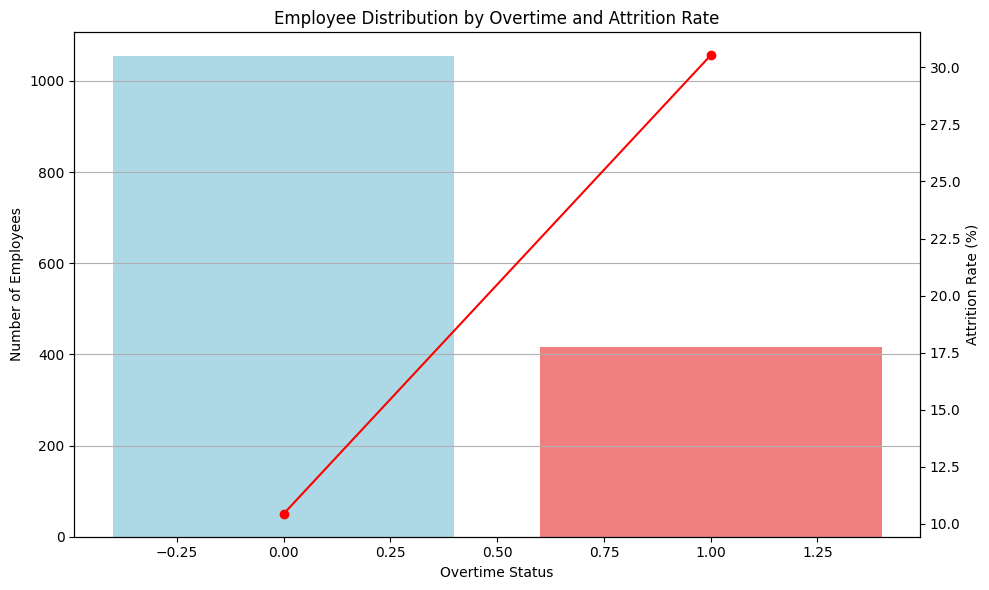

In [ ]:
# Create a grouped bar plot for overtime distribution and attrition
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for employee distribution (overtime and no overtime)
ax1.bar(df_overtime_analysis.index, df_overtime_analysis['Overtime Counts'], color=['lightblue', 'lightcoral'], label='Employee Count')
ax1.set_xlabel('Overtime Status')
ax1.set_ylabel('Number of Employees')
ax1.set_title('Employee Distribution by Overtime and Attrition Rate')
ax1.grid(axis='y')

# Create a second y-axis to plot attrition rates
ax2 = ax1.twinx()
ax2.plot(df_overtime_analysis.index, df_overtime_analysis['Attrition by Overtime (%)'], color='red', marker='o', label='Attrition Rate')
ax2.set_ylabel('Attrition Rate (%)')

# Adjust the layout and show the plot
fig.tight_layout()
plt.show()

Employees who **do not work overtime** exhibit an attrition rate of **12.36%**, which is relatively low. In contrast, **those working overtime** face a significantly higher attrition rate of **30.05%**, **more than double** that of their non-overtime counterparts.

The analysis clearly indicates that **overtime has a substantial impact on employee attrition**. With an attrition rate of **30.05% among those working overtime** compared to **12.36% for those who don't**, it's evident that employees who work overtime are more likely to leave the company. This trend suggests that **excessive workload or a lack of work-life balance** could be critical factors contributing to higher turnover.

**Employers should consider managing overtime more effectively**, potentially through better workload distribution or by offering support to those required to work beyond regular hours. **Addressing this issue could significantly reduce attrition and enhance employee retention.**


### Marital Status

The marital status of employees—whether single, married, or divorced—can significantly influence their decisions regarding organizational commitment and potential attrition. These personal and social commitments often shape employees' work-life balance, impacting their job satisfaction and overall engagement with the company. Understanding these dynamics is crucial for organizations seeking to develop effective retention strategies.

In [ ]:
# Count of employees in each marital status category
marital_status_counts = t_data[['MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']].sum().reset_index()
marital_status_counts.columns = ['Marital Status', 'Marital Status Counts']

# Calculate percentage of employees in each marital status category
marital_status_counts['Marital Status Percentage (%)'] = (marital_status_counts['Marital Status Counts'] / len(t_data) * 100).round(2)

# Create a new column for marital status based on the individual columns
t_data['MaritalStatus'] = t_data[['MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']].idxmax(axis=1)

# Calculate the attrition rate for each marital status
marital_status_attrition = t_data.groupby('MaritalStatus')['Attrition'].mean().reset_index()
marital_status_attrition.columns = ['Marital Status', 'Attrition by Marital Status (%)']
marital_status_attrition['Attrition by Marital Status (%)'] = (marital_status_attrition['Attrition by Marital Status (%)'] * 100).round(2)

# Merge all the information into a single DataFrame
df_marital_status_analysis = pd.merge(marital_status_counts, marital_status_attrition, on='Marital Status').set_index('Marital Status')

# Display the final DataFrame
df_marital_status_analysis

,Marital Status Counts,Marital Status Percentage (%),Attrition by Marital Status (%)
Marital Status,,,
MaritalStatus_Divorced,327,22.24,10.09
MaritalStatus_Married,673,45.78,12.48
MaritalStatus_Single,470,31.97,25.53


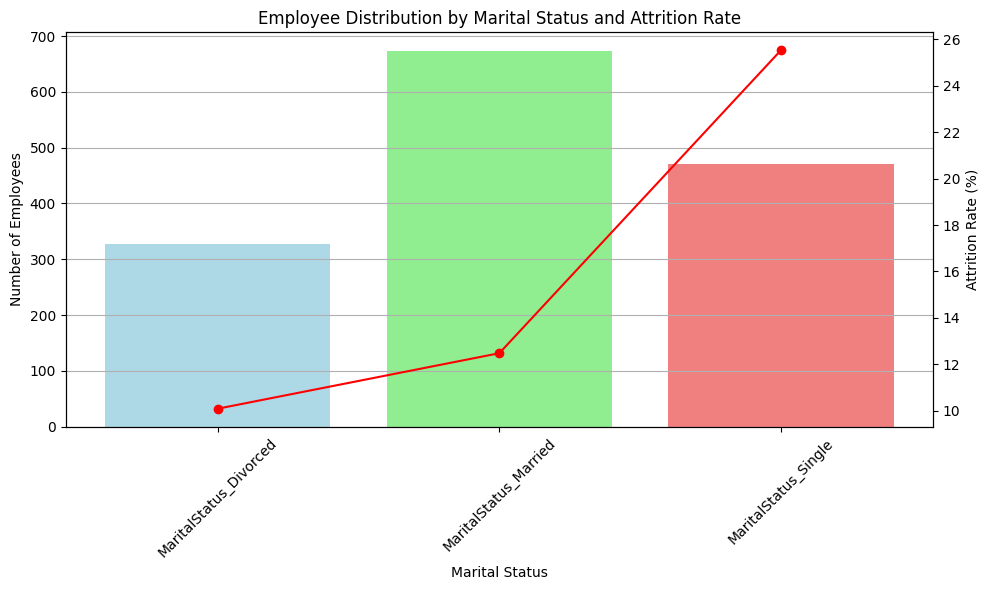

In [ ]:
# Calculate attrition counts by marital status
attrition_counts = t_data.groupby('MaritalStatus')['Attrition'].value_counts().unstack().fillna(0)

# Calculate attrition percentages
attrition_percentage = attrition_counts.div(attrition_counts.sum(axis=1), axis=0) * 100

# Create a grouped bar plot for marital status distribution and attrition
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for employee distribution by marital status
ax1.bar(df_marital_status_analysis.index, df_marital_status_analysis['Marital Status Counts'], color=['lightblue', 'lightgreen', 'lightcoral'], label='Employee Count')
ax1.set_xlabel('Marital Status')
ax1.set_ylabel('Number of Employees')
ax1.set_title('Employee Distribution by Marital Status and Attrition Rate')
ax1.set_xticks(range(len(df_marital_status_analysis.index)))
ax1.set_xticklabels(df_marital_status_analysis.index, rotation=45)
ax1.grid(axis='y')

# Create a second y-axis to plot attrition rates
ax2 = ax1.twinx()
ax2.plot(df_marital_status_analysis.index, df_marital_status_analysis['Attrition by Marital Status (%)'], color='red', marker='o', label='Attrition Rate')
ax2.set_ylabel('Attrition Rate (%)')

# Adjust the layout and show the plot
fig.tight_layout()
plt.show()

The data reveals that the majority of employees in the dataset are married, followed by single employees, with divorced individuals representing a smaller proportion.

Analysis shows that **single employees experience the highest attrition rate**, significantly exceeding that of both married and divorced employees. In fact, the attrition rate for single employees is more than double that of divorced employees and considerably higher than that of their married counterparts.

This trend suggests that marital status plays a critical role in employee attrition within the organization. The elevated attrition rate among single employees may point to a need for **targeted retention strategies** aimed at this demographic, as they appear more prone to leaving the organization. Factors influencing this may include career mobility, social dynamics, job satisfaction levels, the quest for work-life balance, and transitional life circumstances.

In contrast, married employees, who make up the largest segment of the workforce, demonstrate a relatively lower attrition rate. This insight can be invaluable for HR departments, enabling them to develop focused interventions that cater to the unique needs and concerns of employees across different marital status groups. Ultimately, addressing these factors can lead to enhanced employee retention and overall satisfaction within the organization.

## 3.5 Conclusions for the EDA

The analysis of employee attrition identifies several key factors that significantly impact retention, including age, work-life balance, job satisfaction, job involvement, salary hikes, business travel, department, and overtime.

**Younger employees** (under 36) exhibit a notably higher attrition rate of **21.95%**, compared to **10.39%** for older employees. This suggests that younger staff may be more likely to seek better career growth opportunities or may experience greater dissatisfaction in their roles.

**Work-life balance** is another critical factor affecting turnover. Employees who rate their work-life balance as poor (1 or 2) show attrition rates of **31.25%** and **16.86%**, respectively. This indicates that improving work-life balance for these employees could be an effective strategy to reduce attrition.

**Job satisfaction** also plays a significant role in retention. Employees who report low satisfaction (ratings of 1 or 2) have higher turnover rates (**22.84%** and **16.43%**) compared to those who are highly satisfied (**11.33%**).

**Job involvement** mirrors this trend; employees with low involvement (rating of 1) face a staggering **33.73%** attrition rate, while those with higher engagement (rating of 4) show a much lower attrition rate of **9.03%**. Therefore, fostering employee involvement and recognition could be essential in mitigating this issue.

While **salary hikes** generally aid in retention, raises perceived as insufficient can lead to increased attrition. Employees receiving moderate raises (between **11-14%**) tend to exhibit higher attrition rates, while those receiving larger raises (around **21%**) experience reduced turnover.

**Frequent business travel** correlates with higher attrition rates (**24.91%**), as does **overtime**, with employees working overtime experiencing a **30.05%** attrition rate compared to just **12.36%** for those who do not.

Departmental dynamics also play a role, with the **Sales department** facing the highest attrition rate of **20.63%**, while **Research & Development** maintains a lower rate of **13.84%**.

Regarding **marital status**, the data reveals that most employees in the dataset are married, followed by single employees and a smaller proportion who are divorced. Notably, single employees exhibit the highest attrition rate, more than double that of divorced employees and significantly higher than that of married employees. This indicates that marital status is a crucial factor influencing employee attrition within the organization.

Cross-referencing these findings with our research question, it becomes evident that age and work-life balance play a pivotal role in influencing employee attrition. The higher attrition rates among younger employees suggest that they may indeed value work-life balance more significantly in their decision to leave the company. Conversely, older employees, who tend to have a lower attrition rate, may prioritize different factors in their employment experience. Understanding these dynamics can help organizations tailor their retention strategies to meet the specific needs of different age groups, ultimately fostering a healthier work environment that values employee well-being and satisfaction.

# 4. Method 1: Logistic Regression


## 4.1 Creating the Logistic Regression Model


A logistic regression model is being used to test the hypothesis that **younger employees are more likely to quit their jobs**, with the likelihood of attrition decreasing as employees age. In addition to `Age`, the model incorporates key findings from the exploratory data analysis (EDA) to further explain employee turnover. Specifically, `OverTime`, `WorkLifeBalance`, `MaritalStatus_Single`, `JobRole_Sales Representative`, and `BusinessTravel_Travel_Frequently` are included to capture work-related and demographic factors that influence attrition.

- **OverTime** emerged as the strongest factor positively correlated with attrition in the EDA. Employees working overtime are more likely to leave, potentially due to higher job dissatisfaction and stress.
- **WorkLifeBalance** is included because maintaining a balance between personal and professional life is crucial. The EDA showed that poor work-life balance is associated with a higher likelihood of attrition, indicating that it exacerbates employee turnover.
- **MaritalStatus_Single** was identified as a significant predictor, suggesting that single employees are more prone to attrition compared to their married or divorced colleagues.
- **JobRole_Sales Representative** is included because sales representatives were found to have higher turnover rates, indicating that certain job roles may inherently involve higher attrition risk.
- **BusinessTravel_Travel_Frequently** also demonstrated a positive relationship with attrition, indicating that employees who frequently travel for business might have a higher likelihood of leaving due to the challenges associated with frequent travel.

Incorporating these findings from the EDA ensures that the model examines the effect of **age** on attrition while accounting for broader demographic and work-related influences. This multivariate approach provides a more nuanced understanding of the factors contributing to employee turnover, yielding a clearer assessment of the hypothesis regarding age and attrition.


In [ ]:
# Fit the logistic regression model for attrition based on age, overtime, and work-life balance
logit_model = smf.logit('Attrition ~ Age + OverTime + WorkLifeBalance + MaritalStatus_Single + JobRole_Sales_Representative + BusinessTravel_Travel_Frequently', data=t_data).fit()

# View the summary of the model

print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.373421
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1463
Method:                           MLE   Df Model:                            6
Date:                Sat, 12 Oct 2024   Pseudo R-squ.:                  0.1546
Time:                        08:07:11   Log-Likelihood:                -548.93
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 1.330e-40
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -0.2997      0.456     -0.65


**Interpretation**

The logistic regression results indicate a significant negative relationship between age and employee attrition. The coefficient for `Age` is -0.0456 (p < 0.001), meaning that for each additional year of age, the log odds of an employee leaving the company decrease by approximately 0.0456. This finding supports the hypothesis that younger employees are more likely to quit their jobs compared to older employees.

Although the effect size is moderate, the relationship is still important. Specifically, the odds ratio for **Age** is approximately 0.955, indicating that with each additional year of age, the likelihood of attrition decreases by about 4.5%. This suggests that while **Age** alone may not be the strongest factor, it does have a consistent and meaningful impact on the risk of attrition.

The confidence interval for **Age**, ranging from -0.064 to -0.027, reinforces the importance of age as a predictor. Older employees may be more committed or find it more challenging to leave their current roles compared to younger employees, who might have fewer personal commitments and are therefore more open to new opportunities. Thus, **Age** remains a relevant factor in understanding employee turnover, even if it operates alongside other contributing factors.

Other significant predictors of attrition include:
- `OverTime` (coefficient: 1.4721, p < 0.001): Employees working overtime are significantly more likely to leave.
- `WorkLifeBalance` (coefficient: -0.3241, p = 0.003): Better work-life balance reduces the likelihood of attrition.
- `MaritalStatus_Single` (coefficient: 0.9064, p < 0.001): Single employees are more prone to leaving.
- `JobRole_Sales_Representative` (coefficient: 1.1195, p < 0.001): Sales representatives are more likely to quit.
- `BusinessTravel_Travel_Frequently` (coefficient: 0.6791, p < 0.001): Frequent business travel increases the likelihood of leaving.

In conclusion, while **Age** is a moderate predictor of employee attrition, its negative relationship with turnover indicates that age is an important factor to consider when designing retention strategies. The effect of age is especially relevant when viewed alongside other factors such as overtime and work-life balance, which may amplify or mitigate the likelihood of younger employees leaving the company.


## 4.2 Checking Model Assumptions

### No Multicollinearity


In [ ]:
# Extract the independent variables from your logistic regression model
X = logit_model.model.exog  # Independent variables
vif = pd.DataFrame()

# Calculate VIF for each independent variable
vif["VIF Factor"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
vif["Features"] = logit_model.model.exog_names  # Independent variable names

# Display the VIF factors
print(vif)


   VIF Factor                          Features
0       35.75                         Intercept
1        1.05                               Age
2        1.00                          OverTime
3        1.00                   WorkLifeBalance
4        1.02              MaritalStatus_Single
5        1.04      JobRole_Sales_Representative
6        1.00  BusinessTravel_Travel_Frequently


The **Variance Inflation Factor (VIF)** measures multicollinearity in a regression model, with values above 10 indicating significant multicollinearity and a more conservative threshold being 5. The results indicate that multicollinearity is not a concern for the independent variables in the model:

- The VIF for `Age` is 1.05, suggesting that this variable is almost entirely independent of the other predictors in the model.
- Similarly, the VIF values for `OverTime` (1.00), `WorkLifeBalance` (1.00), `MaritalStatus_Single` (1.02), `JobRole_Sales_Representative` (1.04), and `BusinessTravel_Travel_Frequently` (1.00) are all well below even the conservative threshold of 5, indicating no multicollinearity.
- The **Intercept** has a VIF of 35.75, but this is typical for intercepts and does not indicate multicollinearity among the predictor variables.

Therefore, the inclusion of `Age`, `OverTime`, `WorkLifeBalance`, `MaritalStatus_Single`, `JobRole_Sales_Representative`, and `BusinessTravel_Travel_Frequently` in the model does not introduce multicollinearity, ensuring the reliability of the coefficient estimates.



### Independence of Errors

In [ ]:
# Get the residuals from the logistic regression model
residuals = logit_model.resid_response  # Extract residuals from the fitted logistic model

# Perform the Durbin-Watson test
dw_test = durbin_watson(residuals)
print(f'Durbin-Watson Test: {dw_test}')


Durbin-Watson Test: 1.9278450450313918


**Interpretation**

The Durbin-Watson test checks for autocorrelation in regression residuals, with values near 2 indicating no autocorrelation, while values closer to 0 or 4 suggest positive or negative autocorrelation, respectively.

In this case, the Durbin-Watson statistic is 1.93, which is very close to 2, indicating that there is no significant autocorrelation in the residuals of the logistic regression model. This confirms that the residuals are independent, and the model is not affected by autocorrelation, further supporting the validity of the model.

## 4.3 R-Squared Metrics

In [ ]:
# Number of observations (rows) in the dataset
n = len(t_data)

# McFadden's pseudo R-squared
mcfadden_r2 = 1 - (logit_model.llf / logit_model.llnull)
print(f"McFadden's pseudo R-squared: {mcfadden_r2}")

# Cox & Snell R-Squared
cox_snell_r2 = 1 - np.exp((logit_model.llnull - logit_model.llf) * 2 / n)
print(f"Cox & Snell pseudo R-squared: {cox_snell_r2}")

# Nagelkerke R-Squared
nagelkerke_r2 = cox_snell_r2 / (1 - np.exp(-logit_model.llnull * 2 / n))
print(f"Nagelkerke pseudo R-squared: {nagelkerke_r2}")


McFadden's pseudo R-squared: 0.15457292157093883
Cox & Snell pseudo R-squared: 0.12763565036596103
Nagelkerke pseudo R-squared: -0.08994218236027944


**Interpretation**

In logistic regression, pseudo R-squared metrics, such as McFadden's R-squared, provide an indication of how well the model explains the variability in the outcome. A McFadden's R-squared value between 0.2 and 0.4 is typically considered a good fit, while lower values suggest a modest fit. In this case, the McFadden's pseudo R-squared value is 0.1546, indicating a modest fit, which is common for logistic regression models, particularly when modeling human behavior such as employee attrition.

The Cox & Snell pseudo R-squared value is 0.1276, which also suggests that the model explains some of the variability in the outcome, though it does not indicate a strong fit. This value implies that approximately 12.8% of the variation in employee attrition is accounted for by the model.

The negative Nagelkerke pseudo R-squared value (-0.0899) is unusual, as pseudo R-squared values are generally expected to be positive. This could suggest potential issues with the model or the data, such as model specification problems or unusual data characteristics. Despite this, it is important to note that pseudo R-squared values in logistic regression do not carry the same interpretation as in linear regression and are generally lower.

Overall, while the model does not have a high pseudo R-squared value, it still provides meaningful insights into the factors influencing employee attrition. The emphasis will be placed on the significance and direction of the coefficients, particularly for **Age**, to assess whether the hypothesis regarding younger employees' likelihood of quitting is supported.

## 4.4 Conclusion of Logistic Regression

The logistic regression results indicate that younger employees are more likely to quit, with each additional year of age reducing the likelihood of attrition by approximately 4.5%. Younger employees may be more inclined to leave due to their pursuit of career advancement, a desire for new opportunities, or unmet expectations regarding job satisfaction and work-life balance. At earlier stages in their careers, they may feel a stronger need to explore different roles or organizations to gain experience, and they may also have higher expectations for flexibility, professional development, and growth, leading to turnover if these needs are not met.

On the other hand, older employees might be less inclined to leave their jobs for several reasons. As they advance in their careers, they may have achieved a level of stability, job security, or seniority that makes them more satisfied with their current roles. They may also be more invested in their organizations, having built strong professional relationships and gained valuable organizational knowledge over time. Additionally, older employees may prioritize long-term financial stability, particularly as they approach retirement, making them less likely to take the risks associated with job changes.

Beyond age, the most significant predictors of attrition were working overtime, poor work-life balance, being single, being a sales representative, and frequent business travel. These factors suggest that job conditions and personal circumstances also play a critical role in turnover. Younger employees may be more sensitive to these challenges, whereas older employees, with more experience and possibly more stable work-life arrangements, may have developed coping mechanisms that allow them to navigate these stressors more effectively.

# 5. Method 2: t-test

# 5.1 Introduction


In this section, we want to determine if there is a **significant difference in the work-life balance scores between younger and older employees who left the company**. Specifically, we are interested in whether younger employees (under 36) who quit the company report lower work-life balance scores compared to older employees (36 and older).This hypothesis is driven by key findings from both our Exploratory Data Analysis (EDA) and Logistic Regression results.

**Relevant insights from EDA:**

The EDA revealed several factors that influence employee attrition, with `Age` and `Work-life balance` emerging as critical factors. Notably:

* **Age:** Younger employees (under 36) had an attrition rate of 21.95%, significantly higher than the 10.39% attrition rate for older employees. This suggests that **younger employees are more likely to leave, possibly due to factors such as dissatisfaction with career growth or work-life balance.**

* **Work-Life Balance:** Employees who rated their work-life balance as poor (1 or 2) experienced significantly higher attrition rates (31.25% and 16.86%, respectively). This indicates that **improving work-life balance could be an effective strategy to retain staff.**

In addition to these insights, other factors such as `Job satisfaction`, `Overtime`, and `Salary hikes` were identified as influencing attrition. Employees reporting lower job satisfaction, those who worked overtime, and those who received moderate salary hikes tended to leave at higher rates. Given that **work-life balance is often closely tied to job satisfaction and overtime, it’s plausible that younger employees may be particularly sensitive to poor work-life balance,** which contributes to their higher attrition rates.

**Insights from Logistic Regression:**

The logistic regression analysis further supported these findings, with age showing a significant negative relationship with attrition. This shows that **as employees get older, their likelihood of leaving the company decreases.** This reinforces the idea that **younger employees are more likely to quit**, and the regression model identified **work-life balance and overtime as significant factors affecting attrition.** Specifically, employees with worse work-life balance or those who worked overtime were more likely to leave the company.

These findings from both the EDA and logistic regression strongly suggest that **work-life balance is an important factor influencing younger employees’ decision to leave the company,** while **older employees may prioritize different aspects of their employment experience.**




# 5.2  Hypothesis Testing


As a result of the previous findings, we have formulated the following hypothesis for our t-test analysis to further explore the relationship between age, work-life balance, and attrition.

> **Null Hypothesis (H0):** There is no significant difference in mean work-life balance scores between the two age groups.

> **Alternative Hypothesis (H1):** The mean work-life balance scores of younger employees who leave are less than those of older employees who leave.

To test this, we will conduct a **one-tailed pooled t-test**, comparing two independent samples:


1.  Younger employees (under 36) who quit

2.  Older employees (36 and older) who quit.


The choice of 36 as the age cutoff is based on the median age of all employees in the company, making it a reasonable dividing point between the two age groups. Additionally, we are measuring if one mean is less than the other in H1, which makes our test one tailed.

### 5.2.1 T-Test Assumptions





Before proceeding with the analysis, we need to verify the following assumptions:




* **Normality:** Let’s verify the sample size of both groups. If there are more than 30 observations in each, using the Central Limit Theorem, we can assume the data is normally distributed and proceed with the analysis.

* **Independence:** Since we are conducting pooled t-test, the two samples have to be different (e.g. men and women, adults and children…) and NOT the same group of people before and after a treatment (same children before vs after a vaccine)

* **Homogeneity of Variance:** This can be tested using Levene’s Test or Bartlett’s Test. A non-significant result (p > 0.05) indicates that the assumption of equal variances holds.




## 5.2.2 Assumption verification


### Normality and Central Limit Theorem

In [ ]:
# Filter data for employees who left (Attrition == 1) and split it into 2 groups: younger and older employees
df_left = t_data[t_data['Attrition'] == 1]
younger_employees = df_left[df_left['Age'] < 36]
older_employees = df_left[df_left['Age'] >= 36]

# Extract WorkLifeBalance scores for each group
younger_wlb = younger_employees['WorkLifeBalance']
older_wlb = older_employees['WorkLifeBalance']

# Verify the sample sizes
print(f"Sample size of Younger employees who quit: {younger_wlb.shape[0]}")
print(f"Sample size of Older employees who quit: {older_wlb.shape[0]}")


Sample size of Younger employees who quit: 160
Sample size of Older employees who quit: 77


Let's Visualize the Central Limit Theorem on our data:

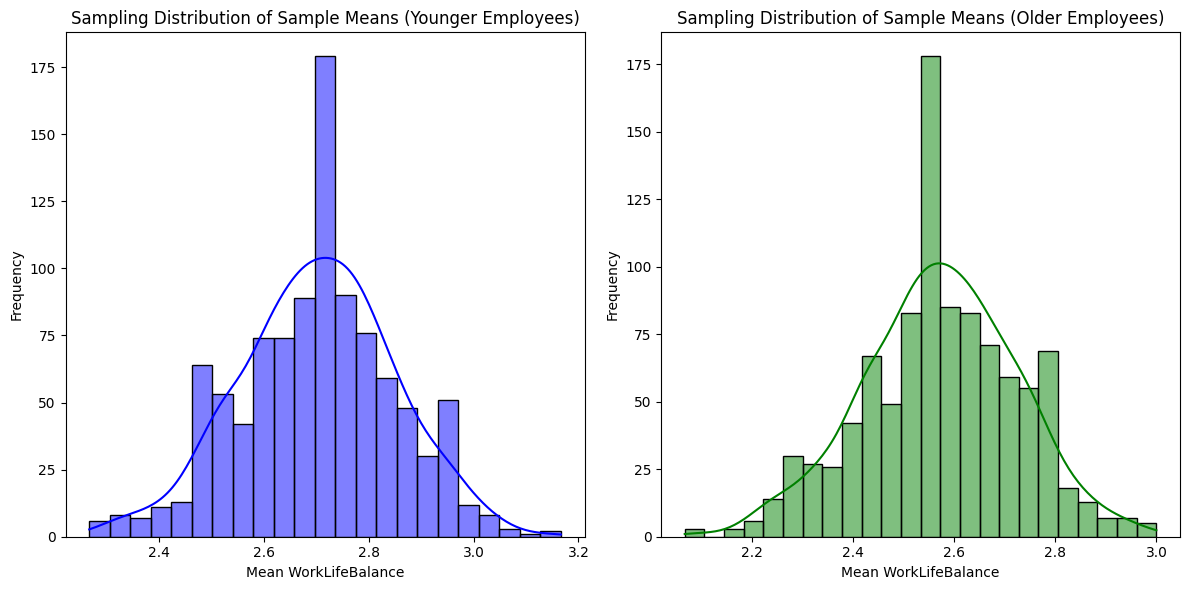

Mean Work-Life Balance (Younger Employees): 2.7017999999999995
Mean Work-Life Balance (Older Employees): 2.5707999999999998


In [ ]:
# Function to simulate sampling distribution of sample means (central limit theorem)
def simulate_sample_means(data, sample_size, num_samples):
    sample_means = []
    for _ in range(num_samples):
        sample = np.random.choice(data, size=sample_size, replace=True)
        sample_means.append(np.mean(sample))
    return sample_means

# Parameters for simulation
sample_size = 30  # CLT typically holds for sample sizes ≥ 30
num_samples = 1000  # Number of samples to simulate

# Simulate sample means for both younger and older employees
younger_sample_means = simulate_sample_means(younger_wlb, sample_size, num_samples)
older_sample_means = simulate_sample_means(older_wlb, sample_size, num_samples)

# Plot the distribution of sample means
plt.figure(figsize=(12, 6))

# Plot for younger employees
plt.subplot(1, 2, 1)
sns.histplot(younger_sample_means, kde=True, color='blue')
plt.title('Sampling Distribution of Sample Means (Younger Employees)')
plt.xlabel('Mean WorkLifeBalance')
plt.ylabel('Frequency')

# Plot for older employees
plt.subplot(1, 2, 2)
sns.histplot(older_sample_means, kde=True, color='green')
plt.title('Sampling Distribution of Sample Means (Older Employees)')
plt.xlabel('Mean WorkLifeBalance')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Optional: Calculate and print the mean of the sample means
mean_younger = np.mean(younger_sample_means)
mean_older = np.mean(older_sample_means)

print(f"Mean Work-Life Balance (Younger Employees): {mean_younger}")
print(f"Mean Work-Life Balance (Older Employees): {mean_older}")


### Interpretation
The plots show the sampling distributions of the mean work-life balance scores for both younger employees (under 36) and older employees (36 and older) who left the company.

Both distributions of sample means appear to be approximately **normal,** despite the fact that the underlying work-life balance data might not follow a normal distribution. This confirms the **Central Limit Theorem**, which states that with sufficiently large sample sizes, the distribution of sample means will approach normality.

The mean of the sampling distribution for younger employees (2.7) is slightly higher than that of older employees, (2.5) suggesting that younger employees who left the company may not have had worse work-life balance on average compared to older employees.

The application of the Central Limit Theorem **justifies the use of a t-test** to compare the mean work-life balance scores between younger and older employees. The normally shaped distributions of the sample means allow us to confidently proceed with the hypothesis test, as the assumption of normality for the t-test is reasonably satisfied. This indicates that, based on these results, younger employees who quit may not experience lower work-life balance than their older counterparts, but further **statistical testing (t-test) will determine if any difference is statistically significant.**

### Homogenity of variances

In [ ]:
levene_test = stats.levene(younger_wlb, older_wlb)

print(f"Levene’s Test for Equality of Variances: p-value = {levene_test.pvalue}")

Levene’s Test for Equality of Variances: p-value = 0.5211557740844479


The Levene’s Test for equality of variances returned a **p-value = 0.34**

> **Null Hypothesis (H0) of Levene's Test:** The variances of the two groups (younger and older employees who quit) are equal.

> **Alternative Hypothesis (H1):** The variances are not equal.

Since the p-value is greater than 0.05 (p = 0.3408), we **fail to reject the null hypothesis.** This means that there is **no significant difference in the variances of the work-life balance scores between younger and older employees who quit.**

**The assumption of homogeneity of variances is satisfied**, allowing us to proceed with the pooled t-test (assuming equal variances) for comparing the mean work-life balance scores between younger and older employees.

### Interpretation

**Normality:**
The sample size for both groups (160 for younger employees and 77 for older ones) is greater than 30 observations, therefore the Central Limit theorem applies.

**Independence:** We assume that the data is collected randomly and the two groups are independent of each other (younger vs. older employees), therefore independence holds.

**Homogeneity of Variance:** Using Levene’s Test, the pvalue (p > 0.05) which means that the assumption of equal variances holds.


## 5.2.3 One tailed, pooled t-test

In [ ]:
# Perform two-sample t-test (one-sided)
# Null Hypothesis: mean(younger_wlb) == mean(older_wlb)
# Alternative Hypothesis: mean(younger_wlb) < mean(older_wlb)

# First, we perform a two-sided t-test
t_stat, p_value_two_tailed = stats.ttest_ind(younger_wlb, older_wlb, equal_var=True)

# For a one-sided test, divide the two-tailed p-value by 2 and check the direction
if t_stat < 0:  # We're testing if younger_wlb < older_wlb, and following the scipy documentation to divive pvalue/2
    p_value_one_tailed = p_value_two_tailed / 2
else:
    p_value_one_tailed = 1 - (p_value_two_tailed / 2)

# Output the t-statistic and one-tailed p-value
print(f"T-statistic: {t_stat}")
print(f"One-tailed p-value: {p_value_one_tailed}")

# Interpret the results
alpha = 0.05  # Significance level
if p_value_one_tailed < alpha:
    print("Reject the null hypothesis. There is evidence that the work-life balance for younger employees is lower.")
else:
    print("Fail to reject the null hypothesis. There is no significant evidence that the work-life balance for younger employees is lower.")


T-statistic: 1.1360877679974668
One-tailed p-value: 0.8714614582743052
Fail to reject the null hypothesis. There is no significant evidence that the work-life balance for younger employees is lower.


### Results and interpretation

Let's remind the t-test hypothesis and decision rule:

> **Null Hypothesis (H0):** The mean work-life balance scores for younger and older employees who quit are equal.

> **Alternative Hypothesis (H1):** The mean work-life balance score for younger employees who quit is lower than that for older employees who quit.

**Decision rule:** The threshold we adopt **alpha is 0.05**. In order to confirm the hypothesis test, the following rule is applied: If the p-value is too low (<0.05), H0 must go.

In our case, the p-value(0.88) is >0.05. Therefore we **fail to reject the null hypothesis.** There is **not sufficient evidence to say that the mean work-life balance scores of younger employees who leave are less than those of older employees who leave.**



## 5.3 Conclusion of T-Test
The t-test results suggest that while there may be some difference in work-life balance between younger and older employees, the evidence is not strong enough to conclude that younger employees experience significantly worse work-life balance. Therefore, age does not appear to be a significant factor in determining differences in work-life balance among employees who leave the company.

Even though work-life balance cannot be accepted as a viable measure to determine whether younger employees are more likely to quit, variables related to it, as explored in the EDA, might offer deeper insight into the topic and the hypotheses. These related variables include business travel, job involvement, job satisfaction and overtime. Connecting these findings to broader themes, such as the "New Work" movement, might reveal nuances in work culture preferences.

Additionally, it is important to note that we do not specifically know how work-life balance was measured—whether it is based solely on employee self-evaluation. This could mean a potential bias, as the perceived work-life balance might not fully reflect the actual conditions. It might be beneficial to consider measuring work-life balance using more objective indicators, like those proposed in the EDA, to gain a more accurate understanding of the situation.


# 6. Conclusion

This analysis aims to answer the **research question:**

> "How do age and work-life balance influence employee attrition, and do younger employees value work-life balance more than older employees in their decision to leave the company?"

Through **Exploratory Data Analysis** (EDA), we identified several key factors that contribute to employee attrition, with `Age` and `Work-life Balance` standing out as critical variables. The EDA showed that younger employees (under 36) had a significantly higher attrition rate of 21.95%, compared to just 10.39% for older employees. Additionally, employees with poor work-life balance (ratings of 1 or 2) exhibited higher turnover, with attrition rates of 31.25% and 16.86% respectively. Other important factors identified included `Overtime`, `Job Satisfaction`, and `Business Travel`, all of which influenced attrition. These findings led us to hypothesize that **younger employees may be more likely to leave due to dissatisfaction with work-life balance and other job-related factors**.

The **logistic regression** analysis confirmed a negative relationship between `Age` and `Attrition`. With a coefficient of -0.0456 (p < 0.001), the results indicated that **as employees get older, the likelihood of them quitting decreases**. Specifically, the odds ratio of 0.955 suggests that for every additional year of age, the likelihood of attrition decreases by approximately 4.5%. This finding supports the hypothesis that younger employees are more likely to quit, potentially driven by dissatisfaction with factors such as `Work-life Balance` and `Overtime`. Indeed, the regression also highlighted that **employees who worked overtime were significantly more likely to leave** (coefficient: 1.4721, p < 0.001), while **better work-life balance reduced the likelihood of quitting** (coefficient: -0.3241, p = 0.003). These results point to a clear interaction between age, work-life balance, and job conditions, all of which may disproportionately affect younger employees.

On the other hand, when we conducted a t-test to directly compare the `Work-life Balance` scores of younger employees (under 36) and older employees (36 and older) who quit, we found no statistically significant difference between the two groups. The t-test results suggested that **while younger employees tend to leave the company more frequently, there is no significant evidence to support the claim that they have worse work-life balance than older employees who quit**. This finding contradicts the assumption that work-life balance alone is a major driver of attrition for younger employees.

However, as revealed in the EDA, work-life balance is closely linked to other job-related factors such as overtime, business travel, and marital status. Employees who work overtime, frequently travel for business, or those who are single face higher attrition rates, all of which can influence their perception of work-life balance. With all of those factors in mind, focusing only on work-life balance is insufficient and cannot explain the complexities behind employee turnover.

To gain a clearer picture of why younger employees are more likely to leave, a more comprehensive model that includes overtime, job satisfaction, business travel, and marital status alongside work-life balance would likely provide deeper insights. These interconnected factors collectively contribute to an employee's overall experience and decision to leave, making it necessary to examine them in combination rather than isolation.

This analysis highlights valuable insights into employee attrition but also has limitations that should be addressed in future research. It primarily focused on age and work-life balance, overlooking other critical factors such as Job Satisfaction, Career Development Opportunities, and Company Culture, which could significantly impact attrition. Additionally, the dataset may not reflect industry-specific trends, such as economic fluctuations or employment practices, and its cross-sectional nature only provides a snapshot of employee experiences. Future studies should include a broader range of variables and adopt longitudinal approaches to better understand the evolving perceptions and behaviours related to employee turnover, ultimately leading to more effective retention strategies.